In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 

# import user functions
import UserUtilityFunctions as uf
import UserStatisticalFunctions as usf
import UserVisualization as uv
import UserImputeFunctions as ui

# set seaborn theme
sns.set_theme()

# initializing variables
REMOVE = '** REMOVE ** DROPNANS Prep'
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# initialize DataFrame
df_new = pd.DataFrame(columns=['column'])

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 1.26.4
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


### Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/4CleanFull_Heart_Engineer.pkl")
df_label = pd.read_pickle("../Data/4CleanFull_Label_Engineer.pkl")
df_can = pd.read_pickle("../Data/4CleanFull_CAN_Engineer.pkl")
df_don = pd.read_pickle("../Data/4CleanFull_DON_Engineer.pkl")
df_both = pd.read_pickle("../Data/4CleanFull_BOTH_Engineer.pkl")
df_nominal = pd.read_pickle("../Data/4CleanFull_Nominal_Engineer.pkl")
df_ordinal = pd.read_pickle("../Data/4CleanFull_Ordinal_Engineer.pkl")
df_numeric = pd.read_pickle("../Data/4CleanFull_Numeric_Engineer.pkl")
df_new = pd.read_pickle("../Data/4CleanFull_New_Engineer.pkl")
df_drop = pd.read_pickle("../Data/4CleanFull_Drop_Engineer.pkl")
df_dict = pd.read_pickle("../Data/4CleanFull_Dictionary_Engineer.pkl")
df_object = pd.read_pickle("../Data/4CleanFull_Object_Engineer.pkl")
df_unknown = pd.read_pickle("../Data/4CleanFull_Unknown_Engineer.pkl")
df_date = pd.read_pickle("../Data/4Clean_Date_Engineer.pkl")

# checking for duplicated column name
df.columns[df.columns.duplicated()]

Index([], dtype='object')

### Feature Information

In [3]:
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Label Features: {df_label.shape[0]:,}")
print(f"Candidate Features: {df_can.shape[0]:,}")
print(f"Donor Features: {df_don.shape[0]:,}")
print(f"Both Features: {df_both.shape[0]:,}")
print(f"Nominal Features: {df_nominal.shape[0]:,}")
print(f"Ordinal Features: {df_ordinal.shape[0]:,}")
print(f"Numeric Features: {df_numeric.shape[0]:,}")
print(f"New Features: {df_new.shape[0]:,}")
print(f"Drop Features: {df_drop.shape[0]:,}")
print(f"Dictionary Features: {df_object.shape[0]:,}")
print(f"Object Features: {df_object.shape[0]:,}")
print(f"Unknown Features: {df_unknown.shape[0]:,}")
print(f"Date Features: {df_date.shape[0]:,}")

Heart Dataset Rows: 27,494 & Columns: 250
Label Features: 15
Candidate Features: 128
Donor Features: 90
Both Features: 22
Nominal Features: 177
Ordinal Features: 13
Numeric Features: 61
New Features: 22
Drop Features: 23
Dictionary Features: 0
Object Features: 0
Unknown Features: 0
Date Features: 0


### Remove Unwanted Label Features

In [4]:
# remove unwanted labels
# removeCols = df_label.column[~df_label.column.isin(['TransplantSurvivalDay', 'LengthOfStay', 'TransplantStatus', 'GraftLifeSpanDay','GraftStatus'])].to_list()
removeCols = df_label.column[~df_label.column.isin(['TransplantSurvivalDay', 'LengthOfStay'])].to_list()

# remove features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 13 row(s) from df_label DataFrame.
Remove 0 row(s) from df_can DataFrame.
Remove 0 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 1 row(s) from df_ordinal DataFrame.
Remove 10 row(s) from df_nominal DataFrame.
Remove 2 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['AcuteRejectionEpisode', 'AirwayDehiscencePostTransplant', 'DialysisPostDischarge', 'FunctionalStatusFollowUp', 'GraftFailStatus', 'GraftLifeSpanDay', 'GraftStatus', 'LastFollowupNumber', 'PacemakerPostTransplant', 'RecipientStatus', 'RejectionTreatmentWithinOneYear', 'StrokePostTransplant', 'TransplantStatus']

Total Row(s) & Column(s) Before Removing Column(s): 27,494 & columns: 250
Total Row(s) & Column(s) After Removing Column(s): 27,494 & columns: 237


### Candidate Survival Information

In [5]:
# total NaNs
print("Total NaNs for TransplantSurvivalDay: ", df.TransplantSurvivalDay.isna().sum())
print("Total NaNs for LengthOfStay: ", df.LengthOfStay.isna().sum())
# remove rows where TransplantSurvivalDay is NaN
# df = df.dropna(subset=['TransplantSurvivalDay'])
# print
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")

Total NaNs for TransplantSurvivalDay:  425
Total NaNs for LengthOfStay:  887
Heart Dataset Rows: 27,494 & Columns: 237


In [6]:
# labels
pd.DataFrame(df[['TransplantSurvivalDay','LengthOfStay']].describe()).T

,count,mean,std,min,25%,50%,75%,max
TransplantSurvivalDay,27069.0,1274.198012,1020.204697,0.0,364.0,1093.0,2058.0,3861.0
LengthOfStay,26607.0,22.548878,25.934613,0.0,11.0,16.0,24.0,823.0


In [7]:
# sanity check
uf.datatypeDF(df, display=True)

Total Data feature count:  237

Boolean feature count: 0
Category feature count: 77
Numeric feature count: 59
Object feature count: 101
Other feature count: 0

Total feature count:  237


### Copy DataFrame

In [8]:
# remove NaNs
df = df.dropna(subset=['TransplantSurvivalDay','LengthOfStay'])
df = df.reset_index(drop=True)
# copy dataframe
df_impute = df.copy()
# print shape
print(f"Orginal Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Impute Heart Dataset Rows: {df_impute.shape[0]:,} & Columns: {df_impute.shape[1]:,}")

Orginal Heart Dataset Rows: 26,600 & Columns: 237
Impute Heart Dataset Rows: 26,600 & Columns: 237


### Numeric Features

In [9]:
# only numerical features
numericCols = df_numeric.column.to_list()

# remove label
numericCols.remove('TransplantSurvivalDay')

# display
df[numericCols].head()

,Age_DON,Age_CAN,BMI_CAN,BMI_DON,BloodUreaNitrogenLevel_DON,WeightKg_DON,WeightKg_CAN,HeightCm_CAN,HeightCm_DON,Creatinine_DON,CreatinineTransplant_CAN,CreatinineRegistration_CAN,HemodynamicsRegistration_CO_CAN,HemodynamicsTransplant_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsRegistration_SYS_CAN,HemodynamicsTransplant_SYS_CAN,TotalDayWaitList_CAN,TotalBilirubinTransplant_CAN,TerminalTotalBilirubin_DON,OrganRecovery_PCO2_DON,Level_SGOT_AST_DON,Level_SGOT_ALT_DON,DistanceFromDonorHospitaltoTXCenter,LengthOfStay,Hematocrit_DON,IschemicTimeHour_DON,BloodPH_DON,LV_EjectionFractionPercent_DON,LungPO2_DON,LungPO2_FIO2_DON,Age_Difference,Age_Addition,HeightCm_Difference,HeightCm_Addition,WeightKg_Difference,WeightKg_Addition,BMI_Difference,BMI_Addition,Creatinine_Difference_CAN,Creatinine_Addition_CAN,Creatinine_Mean_CAN,Hemodynamics_Mean_CO_RT_CAN,Hemodynamics_Mean_PA_DIA_RT_CAN,Hemodynamics_Mean_PA_MN_RT_CAN,Hemodynamics_Mean_PCW_RT_CAN,Hemodynamics_Mean_SYS_RT_CAN,Hemodynamics_Interaction_Mean_CAN,Hemodynamics_Addition_Mean_CAN,Level_SGOT_Difference_DON,Level_SGOT_Addition_DON,TotalBilirubin_Difference,TotalBilirubin_Addition
0,31.0,45,38.100753,61.957151,18.0,107.0,65.8,172.7,172.7,1.30,1.00,1.3,2.50,2.50,34.0,34.0,37.0,37.0,36.0,36.0,50.0,50.0,11,3.6,0.4,40.0,46.0,40.0,83.0,76.0,26.2,4.9,7.38,60.0,182.0,47.0,14.0,76.0,0.0,345.4,-41.2,172.8,-23.856398,100.057904,0.30,2.30,1.150,2.50,34.0,37.0,36.5,50.0,2.295852e+06,157.5,-6.0,86.0,3.2,4.0
1,30.0,36,39.158576,38.853503,29.0,67.1,72.6,185.4,172.7,0.70,0.70,2.3,2.10,4.60,39.0,8.0,46.0,18.0,31.0,4.0,53.0,28.0,348,0.9,0.8,28.0,38.0,171.0,0.0,10.0,27.8,3.1,7.50,55.0,323.0,100.0,6.0,66.0,12.7,358.1,5.5,139.7,0.305073,78.012079,1.60,3.00,1.500,3.35,23.5,32.0,25.0,40.5,7.614011e+05,121.0,133.0,209.0,0.1,1.7
2,15.0,58,60.467770,34.705882,15.0,59.0,106.0,175.3,170.0,0.74,2.19,1.4,5.00,4.40,23.0,21.0,32.0,22.0,13.0,13.0,52.0,28.0,55,1.2,0.7,41.0,445.0,217.0,0.0,21.0,25.4,1.4,7.40,60.0,401.0,100.0,43.0,73.0,5.3,345.3,47.0,165.0,25.761887,95.173652,-0.79,3.59,1.795,4.70,22.0,27.0,22.5,40.0,5.346008e+05,111.5,-228.0,662.0,0.5,1.9
3,47.0,66,62.696629,70.674847,29.0,115.2,111.6,178.0,163.0,1.34,1.35,1.1,4.80,4.80,12.0,12.0,22.0,22.0,12.0,12.0,34.0,34.0,392,0.7,0.3,36.0,248.0,165.0,252.0,32.0,38.3,3.5,7.37,60.0,267.0,100.0,19.0,113.0,15.0,341.0,-3.6,226.8,-7.978217,133.371476,-0.25,2.45,1.225,4.80,12.0,22.0,17.0,34.0,1.525923e+05,85.0,-83.0,413.0,0.4,1.0
4,22.0,70,41.860465,61.782395,70.0,113.0,72.0,172.0,182.9,5.10,0.80,0.8,4.75,4.75,15.0,15.0,20.0,20.0,15.0,15.0,30.0,30.0,42,0.8,0.5,33.0,137.0,174.0,60.0,26.0,30.7,2.8,7.51,55.0,209.0,100.0,48.0,92.0,-10.9,354.9,-41.0,185.0,-19.921930,103.642860,0.00,1.60,0.800,4.75,15.0,20.0,17.5,30.0,1.575003e+05,82.5,37.0,311.0,0.3,1.3


In [10]:
print(sorted(numericCols))

['Age_Addition', 'Age_CAN', 'Age_DON', 'Age_Difference', 'BMI_Addition', 'BMI_CAN', 'BMI_DON', 'BMI_Difference', 'BloodPH_DON', 'BloodUreaNitrogenLevel_DON', 'CreatinineRegistration_CAN', 'CreatinineTransplant_CAN', 'Creatinine_Addition_CAN', 'Creatinine_DON', 'Creatinine_Difference_CAN', 'Creatinine_Mean_CAN', 'DistanceFromDonorHospitaltoTXCenter', 'HeightCm_Addition', 'HeightCm_CAN', 'HeightCm_DON', 'HeightCm_Difference', 'Hematocrit_DON', 'HemodynamicsRegistration_CO_CAN', 'HemodynamicsRegistration_PA_DIA_CAN', 'HemodynamicsRegistration_PA_MN_CAN', 'HemodynamicsRegistration_PCW_CAN', 'HemodynamicsRegistration_SYS_CAN', 'HemodynamicsTransplant_CO_CAN', 'HemodynamicsTransplant_PA_DIA_CAN', 'HemodynamicsTransplant_PA_MN_CAN', 'HemodynamicsTransplant_PCW_CAN', 'HemodynamicsTransplant_SYS_CAN', 'Hemodynamics_Addition_Mean_CAN', 'Hemodynamics_Interaction_Mean_CAN', 'Hemodynamics_Mean_CO_RT_CAN', 'Hemodynamics_Mean_PA_DIA_RT_CAN', 'Hemodynamics_Mean_PA_MN_RT_CAN', 'Hemodynamics_Mean_PCW_RT

#### Data Dictionary

In [11]:
df_dict[df_dict.Feature.isin(numericCols)]

,Feature,Description,Form,FeatureStartDate,FeatureEndDate,FormSection,DataType,SASAnalysisFormat,Comment,OrginalFeature,FeatureType,Information
7,Age_CAN,RECIPIENT AGE (YRS),TRR-CALCULATED,1987-10-01,NaT,RECIPIENT INFORMATION,NUM,,,AGE,Numeric,
8,Age_DON,DONOR AGE (YRS),DDR/LDR-CALCULATED,1987-10-01,NaT,DONOR INFORMATION,NUM,,,AGE_DON,Numeric,
16,BMI_DON,Donor BMI - Pre/At Donation Calculated,CALCULATED,NaT,NaT,,NUM,,,BMI_DON_CALC,Numeric,
21,BloodUreaNitrogenLevel_DON,DECEASED DONOR-TERMINAL BLOOD UREA NITROGEN,DDR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,,,BUN_DON,Numeric,
45,Creatinine_DON,DECEASED DONOR-TERMINAL LAB CREATININE,DDR,1994-04-01,NaT,CLINICAL INFORMATION,NUM,,,CREAT_DON,Numeric,
46,CreatinineTransplant_CAN,RECIPIENT SERUM CREATININE AT TIME OF TX,TRR,1994-04-01,NaT,PRETRANSPLANT CLINICAL INFORMATION,NUM,,,CREAT_TRR,Numeric,
62,TotalDayWaitList_CAN,TOTAL DAYS ON WAITING LIST,CALCULATED,NaT,NaT,,NUM,,,DAYSWAIT_CHRON,Numeric,
77,DistanceFromDonorHospitaltoTXCenter,DISTANCE FROM DONOR HOSP TO TX CENTER (Nautical Miles),CALCULATED,NaT,NaT,,NUM,,,DISTANCE,Numeric,** LABEL ** N/Y/U/X to No/Yes/Unknown/Missing
97,BMI_CAN,Calculated Candidate BMI at Removal/Current Time,CALCULATED,NaT,NaT,,NUM,,,END_BMI_CALC,Numeric,
99,HeightCm_CAN,Calculated Candidate Height in CM at Removal/Current Time,CALCULATED,NaT,NaT,,NUM,,,END_HGT_CM_CALC,Numeric,


### Disply NaNs

In [12]:
# display NaNs
uf.percentageNull(df_impute)

,percentage,NaNCount
Hemodynamics_Addition_Mean_CAN,4.048872,1077
Hemodynamics_Interaction_Mean_CAN,4.048872,1077
Hemodynamics_Mean_PCW_RT_CAN,3.781955,1006
HemodynamicsRegistration_PCW_CAN,3.357143,893
HemodynamicsTransplant_PCW_CAN,3.357143,893
Hemodynamics_Mean_CO_RT_CAN,2.000000,532
HemodynamicsTransplant_CO_CAN,2.000000,532
HemodynamicsRegistration_CO_CAN,2.000000,532
HemodynamicsRegistration_PA_MN_CAN,1.616541,430
Hemodynamics_Mean_PA_MN_RT_CAN,1.616541,430


### Impute Numeric Features
##### `KNN Impute:` Impute missing values in datasets using the k-Nearest Neighbors algorithm. 
- It replaces missing values with estimates based on similar data points in the dataset.
- For each sample with missing values, it finds the k nearest neighbors in the dataset.
    - It then imputes the missing value using the mean or weighted average of those neighbors' values.
- Preserves the original variable distribution.
- Does not assume any underlying data distribution.
- Can handle complex relationships in the data.
- KNN Imputation is a flexible and effective method for handling missing data, particularly when the relationships between variables are complex or non-linear.

##### Gaussian Mixture Model (GMM)
- Gaussian Mixture Model (GMM) imputation is a probabilistic approach to handling missing data by leveraging the Gaussian Mixture Model to estimate missing values based on the distribution of observed data.
- The dataset is assumed to follow a mixture of multiple Gaussian distributions.
- The Expectation-Maximization (EM) algorithm is used to estimate the parameters (means, covariances, and weights) of the Gaussian components.
Classify Data Points into Components
- Each data point is assigned a probability of belonging to each Gaussian component.
    - Impute Missing Values
        - If a feature has missing values, the missing entries are estimated using conditional probabilities derived from the Gaussian distributions.
        - Given an incomplete data point, the missing values are estimated using the conditional expectation based on the component distributions.
            - Advantages:
                - Flexible modeling: Captures multimodal distributions better than simple mean or median imputation.
                - Probabilistic approach: Accounts for uncertainty in missing data.
                - Works well with continuous data.

#### Hemodynamics

In [13]:
features = uf.getFeatureList(df_impute, 'HemodynamicsRegistration|HemodynamicsTransplant')

                                       count       mean        std   min    25%    50%    75%    max
HemodynamicsRegistration_CO_CAN      26068.0   4.272608   1.356561  0.39   3.33   4.11   5.00   15.0
HemodynamicsRegistration_PA_DIA_CAN  26205.0  20.459653   8.682346  0.00  14.00  20.00  26.00   91.0
HemodynamicsRegistration_PA_MN_CAN   26170.0  28.527231  10.195191  0.00  21.00  28.00  36.00   96.0
HemodynamicsRegistration_PCW_CAN     25707.0  19.124673   8.824426  0.00  12.00  19.00  25.00   50.0
HemodynamicsRegistration_SYS_CAN     26212.0  41.869182  14.216455  0.00  31.00  41.00  51.00  130.0
HemodynamicsTransplant_CO_CAN        26068.0   4.521948   1.456154  0.20   3.50   4.38   5.32   15.0
HemodynamicsTransplant_PA_DIA_CAN    26205.0  19.168869   8.484892  0.00  13.00  18.00  25.00  110.0
HemodynamicsTransplant_PA_MN_CAN     26170.0  27.031698   9.918232  0.00  20.00  26.00  34.00  110.0
HemodynamicsTransplant_PCW_CAN       25707.0  17.892101   8.714694  0.00  11.00  17.00  24.

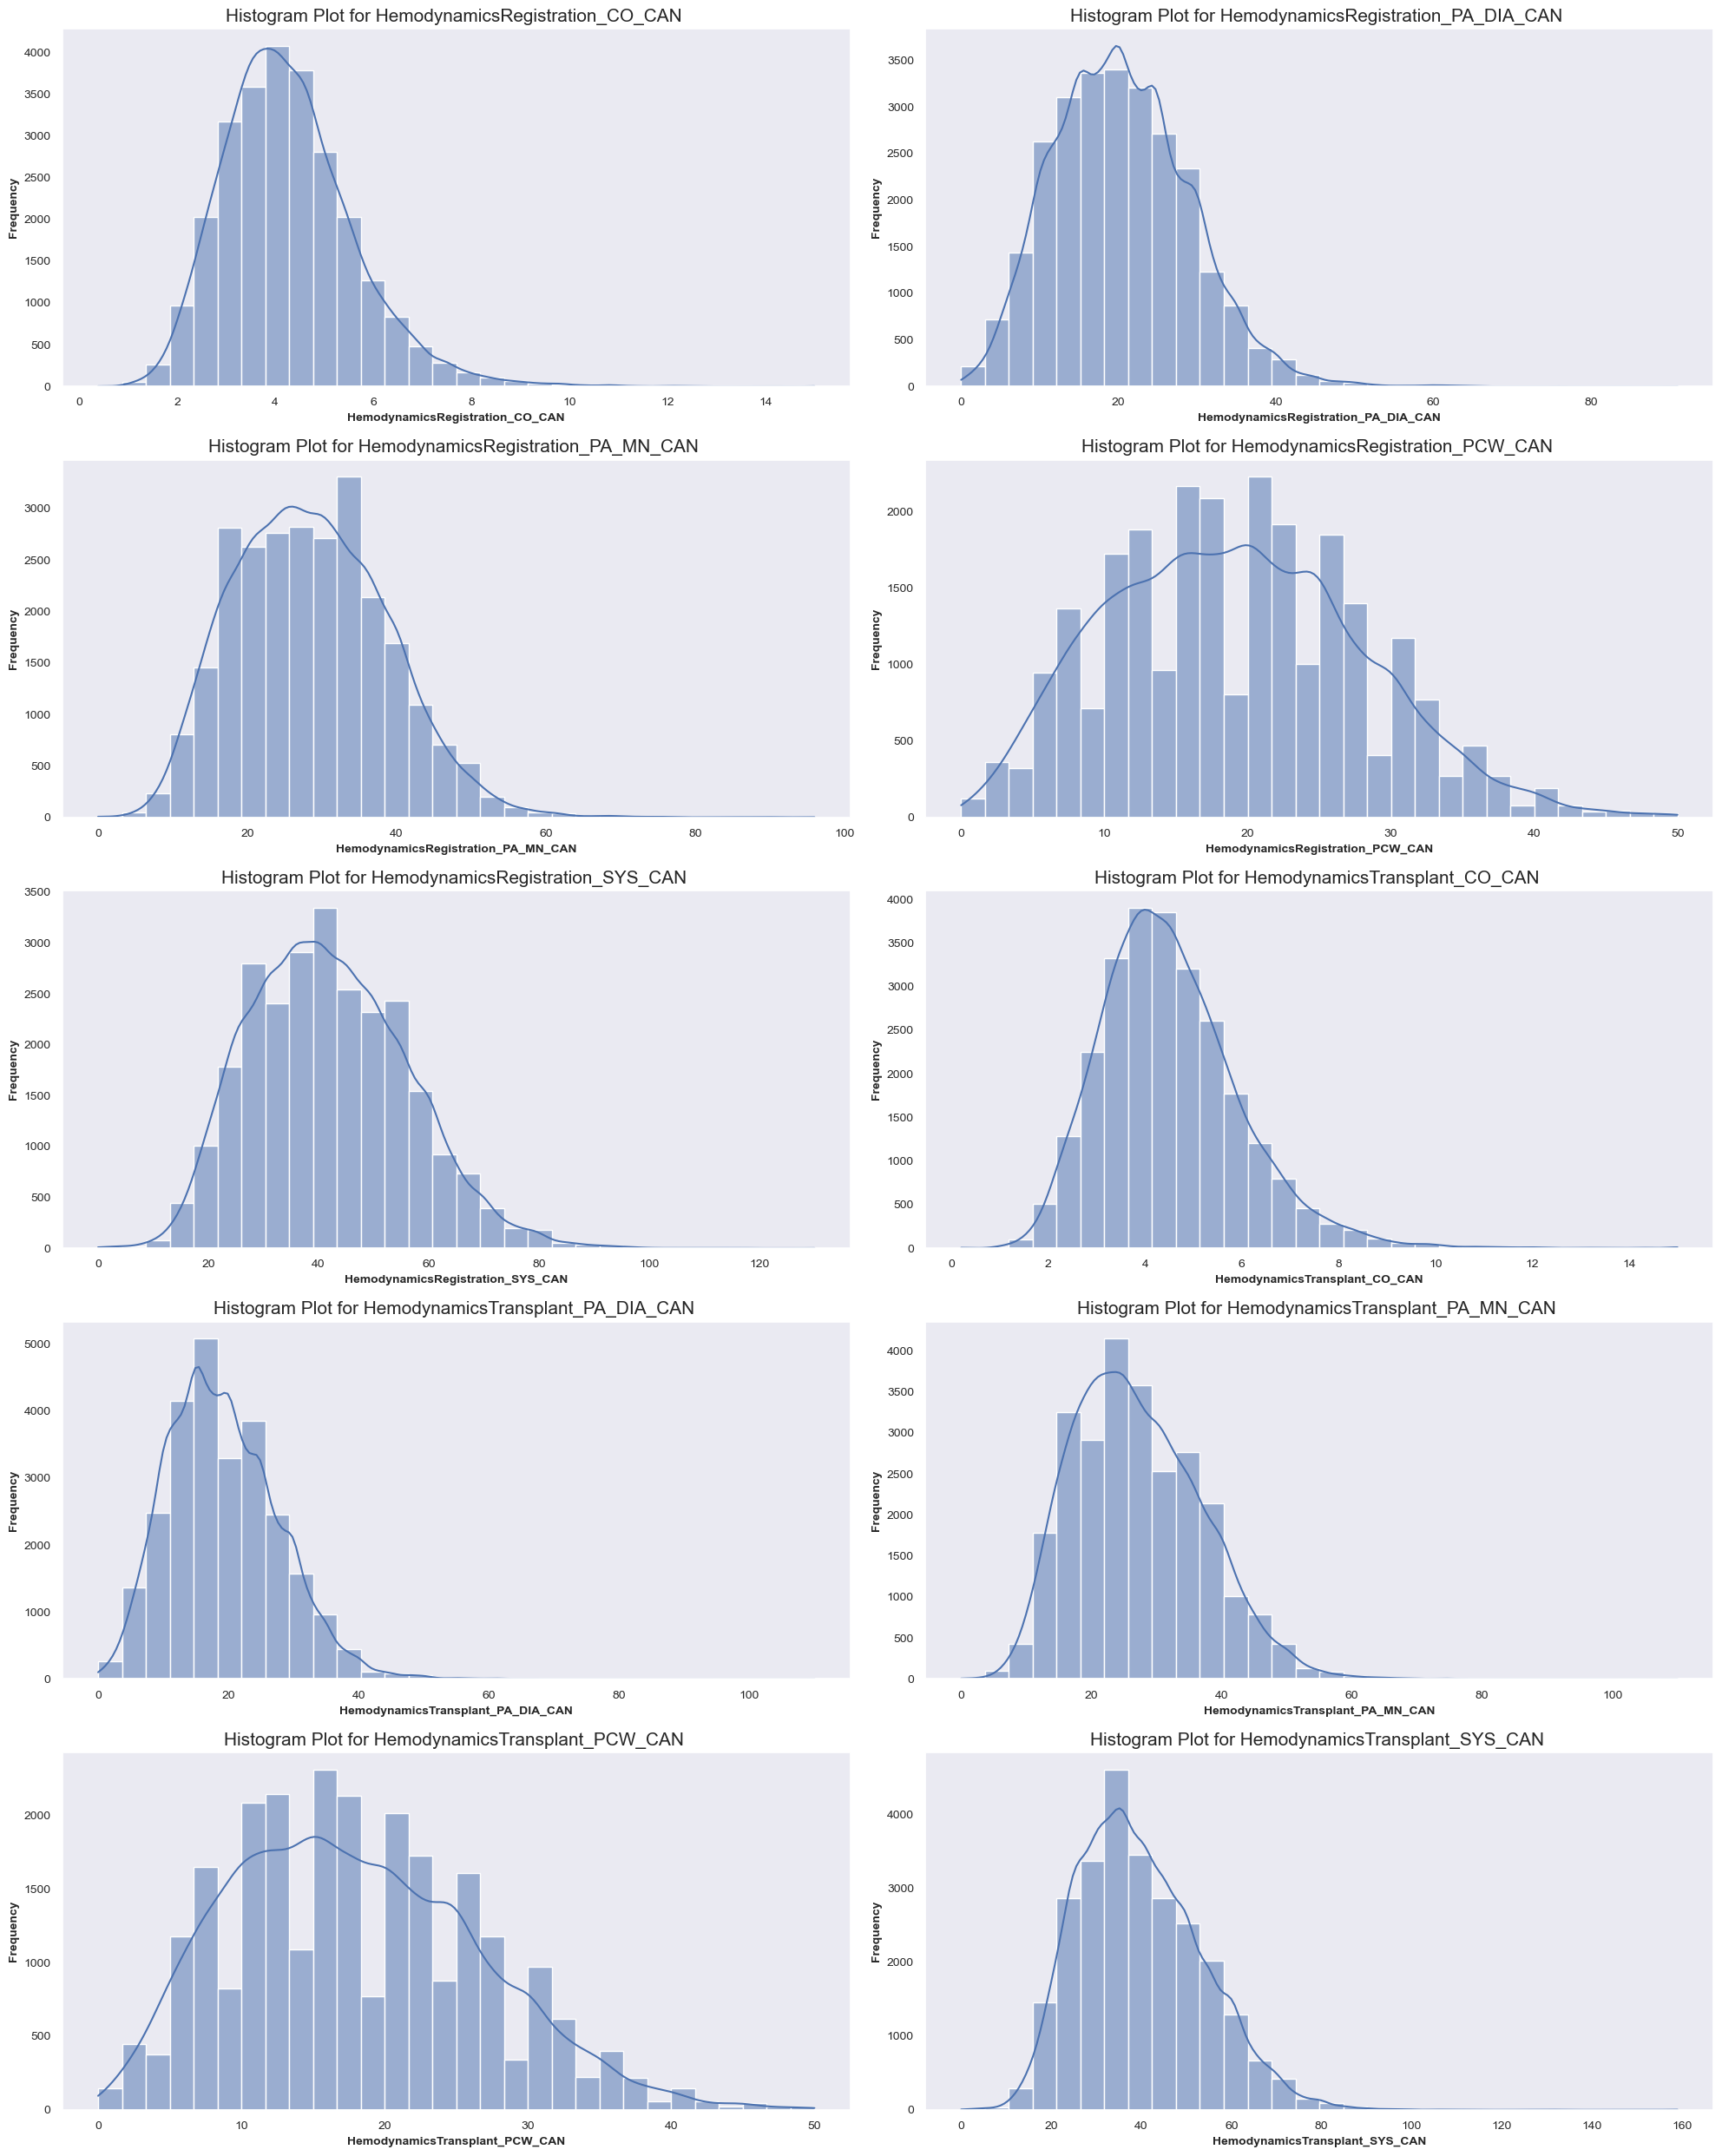

In [14]:
uv.histogramPlot(df_impute, features, bins=30)

Little's MCAR test p-value: 0.0000
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


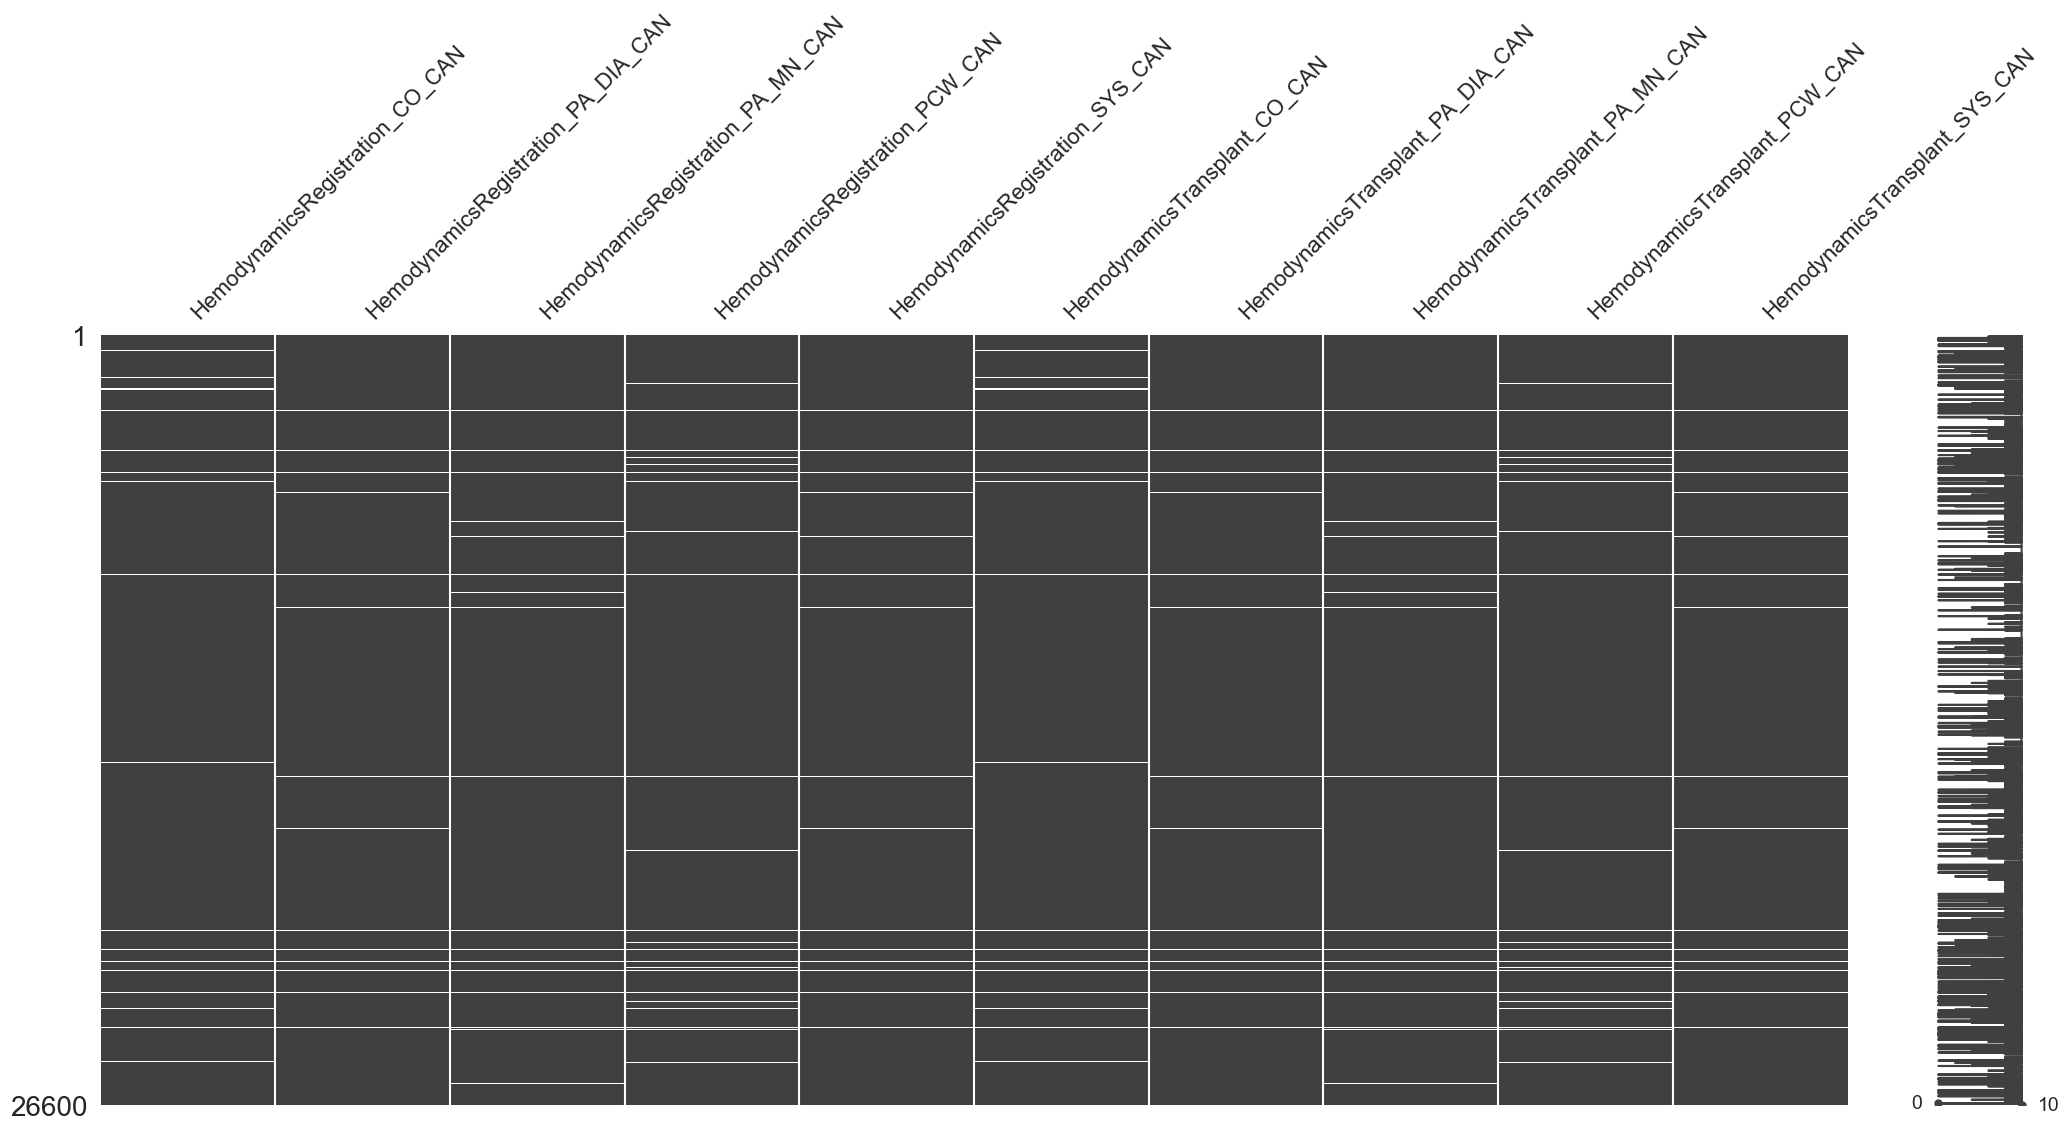

In [15]:
# stats test
usf.testMCAR(df_impute[features])
# plot missing data
uv.plotMissingData(df_impute[features])

##### Combining GMM and KNN Imputation
- Combining Gaussian Mixture Model (GMM) and k-Nearest Neighbors (KNN) imputation methods can be a robust approach for handling data that is not Missing Completely At Random (MNAR).
    - For data that is MNAR, combining these two methods can leverage the strengths of both:
        - GMM Imputation: Use GMM to estimate the missing values based on the overall distribution of the data.
        - KNN Imputation: Apply KNN to refine these estimates by considering the local structure of the data.
        - Taking the mean of the imputed values from both methods can provide a balanced estimate that accounts for both global and local patterns in the data.

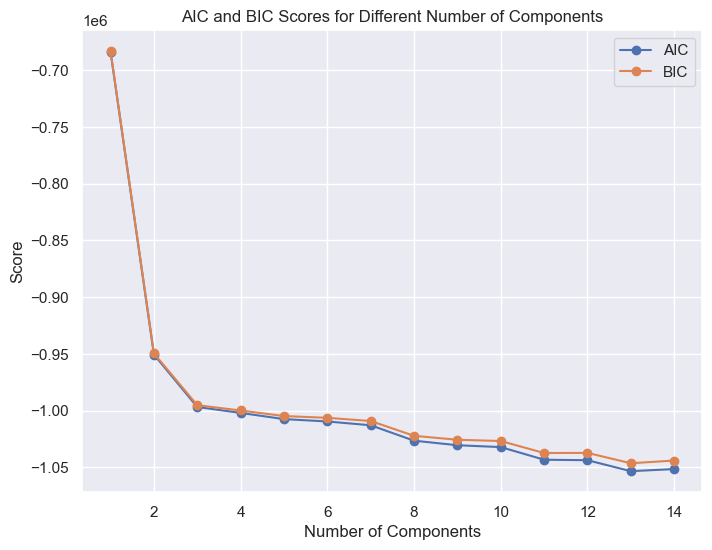

Optimal number of components: 13


In [16]:
# find components
ui.findGaussianMixtureComponents(df[features], component_range=range(1, 15), seed=RANDOM_STATE)

In [17]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=13)

The best n_neighbors for KNN imputer is: 6
The best weights for KNN imputer is: distance


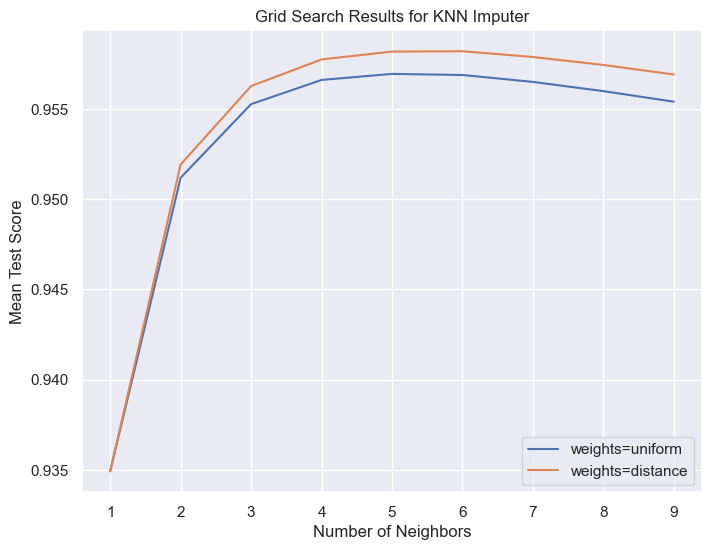

In [18]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features], n_neighbors=range(1, 10), cv=5, figsize=(8,6), flag=True)

In [19]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
HemodynamicsRegistration_CO_CAN,26600.0,4.274112,1.350346,0.39,3.34,4.120000,5.0,15.0
HemodynamicsRegistration_PA_DIA_CAN,26600.0,20.487473,8.653433,0.00,14.00,20.000000,26.0,91.0
HemodynamicsRegistration_PA_MN_CAN,26600.0,28.504454,10.149914,0.00,21.00,28.000000,35.0,96.0
HemodynamicsRegistration_PCW_CAN,26600.0,19.026402,8.724399,0.00,12.00,18.284371,25.0,50.0
HemodynamicsRegistration_SYS_CAN,26600.0,41.812677,14.163142,0.00,31.00,41.000000,51.0,130.0
HemodynamicsTransplant_CO_CAN,26600.0,4.518488,1.448696,0.20,3.50,4.370000,5.3,15.0
HemodynamicsTransplant_PA_DIA_CAN,26600.0,19.251397,8.493752,0.00,13.00,18.000000,25.0,110.0
HemodynamicsTransplant_PA_MN_CAN,26600.0,27.054225,9.885562,0.00,20.00,26.000000,34.0,110.0
HemodynamicsTransplant_PCW_CAN,26600.0,17.827394,8.606431,0.00,11.00,17.000000,24.0,50.0
HemodynamicsTransplant_SYS_CAN,26600.0,39.763216,13.757536,0.00,30.00,38.000000,49.0,159.0


In [20]:
# re-calc Registration & Transplant
df_impute['Hemodynamics_Mean_CO_RT_CAN'] = (df_impute.HemodynamicsRegistration_CO_CAN + df_impute.HemodynamicsTransplant_CO_CAN) / 2
df_impute['Hemodynamics_Mean_PA_DIA_RT_CAN'] = (df_impute.HemodynamicsRegistration_PA_DIA_CAN + df_impute.HemodynamicsTransplant_PA_DIA_CAN) /2
df_impute['Hemodynamics_Mean_PA_MN_RT_CAN'] = (df_impute.HemodynamicsRegistration_PA_MN_CAN + df_impute.HemodynamicsTransplant_PA_MN_CAN) / 2
df_impute['Hemodynamics_Mean_PCW_RT_CAN'] = (df_impute.HemodynamicsRegistration_PA_MN_CAN + df_impute.HemodynamicsTransplant_PCW_CAN) / 2
df_impute['Hemodynamics_Mean_SYS_RT_CAN'] = (df_impute.HemodynamicsRegistration_SYS_CAN + df_impute.HemodynamicsTransplant_SYS_CAN) / 2

# create new feature: add small constant to handle 0 values
df_impute['Hemodynamics_Interaction_Mean_CAN'] = (df_impute.Hemodynamics_Mean_PA_DIA_RT_CAN + 1e-5) * (df_impute.Hemodynamics_Mean_PA_MN_RT_CAN + 1e-5) * \
                                                 (df_impute.Hemodynamics_Mean_PCW_RT_CAN + 1e-5) * (df_impute.Hemodynamics_Mean_SYS_RT_CAN + 1e-5)

df_impute['Hemodynamics_Addition_Mean_CAN'] = df_impute.Hemodynamics_Mean_PA_DIA_RT_CAN +  df_impute.Hemodynamics_Mean_PA_MN_RT_CAN +  \
                                             df_impute.Hemodynamics_Mean_PCW_RT_CAN +  df_impute.Hemodynamics_Mean_SYS_RT_CAN
# print
features = uf.getFeatureList(df_impute, 'Hemodynamics')

                                       count           mean           std           min            25%            50%           75%           max
HemodynamicsRegistration_CO_CAN      26600.0       4.274112  1.350346e+00  3.900000e-01       3.340000       4.120000  5.000000e+00  1.500000e+01
HemodynamicsRegistration_PA_DIA_CAN  26600.0      20.487473  8.653433e+00  0.000000e+00      14.000000      20.000000  2.600000e+01  9.100000e+01
HemodynamicsRegistration_PA_MN_CAN   26600.0      28.504454  1.014991e+01  0.000000e+00      21.000000      28.000000  3.500000e+01  9.600000e+01
HemodynamicsRegistration_PCW_CAN     26600.0      19.026402  8.724399e+00  0.000000e+00      12.000000      18.284371  2.500000e+01  5.000000e+01
HemodynamicsRegistration_SYS_CAN     26600.0      41.812677  1.416314e+01  0.000000e+00      31.000000      41.000000  5.100000e+01  1.300000e+02
HemodynamicsTransplant_CO_CAN        26600.0       4.518488  1.448696e+00  2.000000e-01       3.500000       4.370000  5.300

In [21]:
# display NaNs
uf.percentageNull(df_impute)

,percentage,NaNCount
IschemicTimeHour_DON,0.597744,159
LungPO2_FIO2_DON,0.575188,153
TotalBilirubin_Addition,0.451128,120
TotalBilirubin_Difference,0.451128,120
TotalBilirubinTransplant_CAN,0.296992,79
LungPO2_DON,0.281955,75
OrganRecovery_PCO2_DON,0.259398,69
BloodPH_DON,0.236842,63
Level_SGOT_Addition_DON,0.165414,44
Level_SGOT_Difference_DON,0.165414,44


#### IschemicTimeHour

In [22]:
features = uf.getFeatureList(df_impute, 'IschemicTimeHour')

                        count      mean       std  min  25%  50%  75%   max
IschemicTimeHour_DON  26441.0  3.229935  1.067772  0.3  2.5  3.2  3.9  12.0

:::: NaN Count:
IschemicTimeHour_DON    159


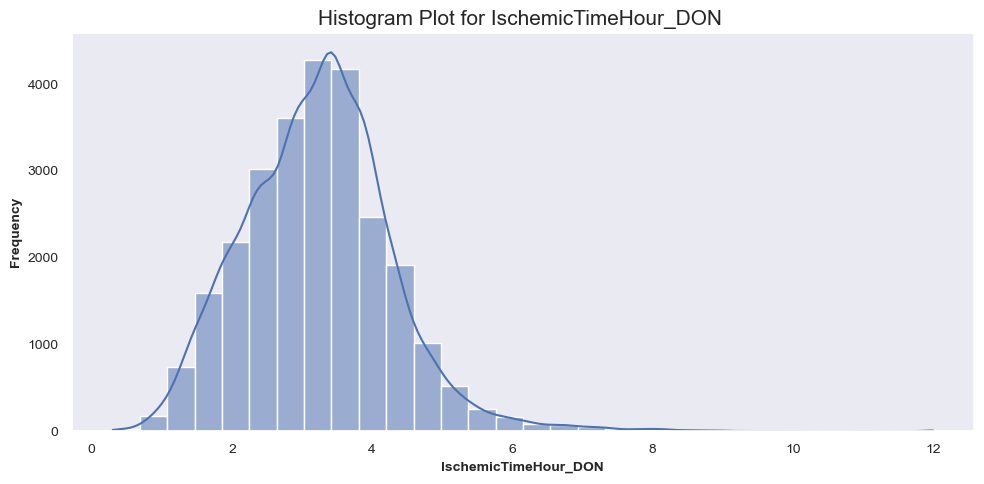

In [23]:
uv.histogramPlot(df_impute, features, bins=30)

In [24]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


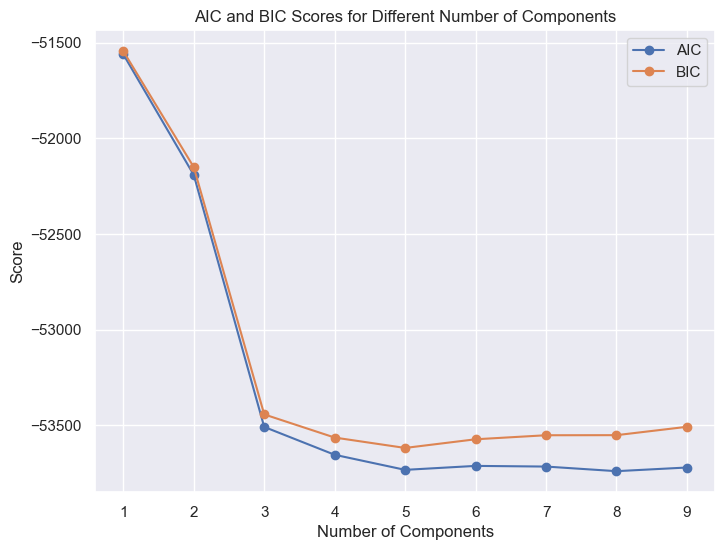

Optimal number of components: 5


In [25]:
# find components
ui.findGaussianMixtureComponents(df[features], RANDOM_STATE)

In [26]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=5)

The best n_neighbors for KNN imputer is: 2
The best weights for KNN imputer is: distance


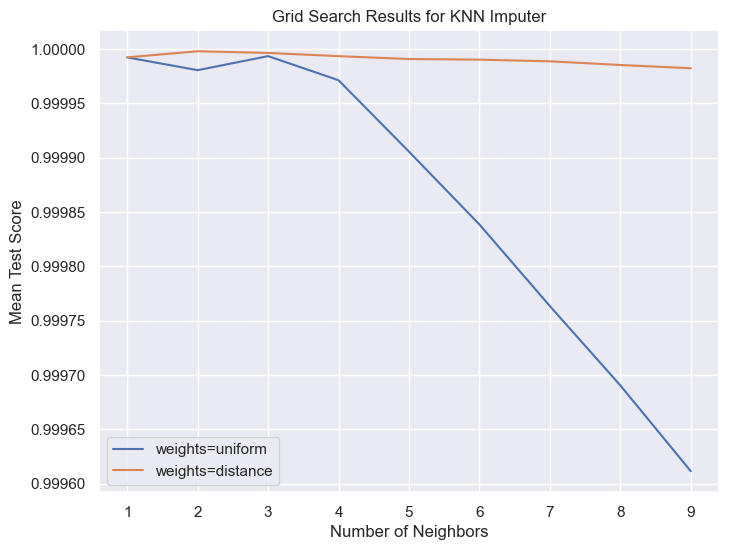

In [27]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [28]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
IschemicTimeHour_DON,26600.0,3.229909,1.065299,0.3,2.5,3.2,3.9,12.0


#### LungPO2

In [29]:
features = uf.getFeatureList(df_impute, 'LungPO2')

                    count unique      top   freq        mean         std   min    25%    50%    75%    max
LungPO2_DON       26525.0    NaN      NaN    NaN  281.005155  159.559636  7.38  131.0  258.0  425.0  698.0
LungPO2_Done_DON    26600      3  Unknown  19146         NaN         NaN   NaN    NaN    NaN    NaN    NaN
LungPO2_FIO2_DON  26447.0    NaN      NaN    NaN   82.074867   25.592334   1.0   60.0  100.0  100.0  100.0

:::: NaN Count:
LungPO2_DON          75
LungPO2_Done_DON      0
LungPO2_FIO2_DON    153


In [30]:
# add to removeCols list
removeCols = features

#### TotalBilirubin

In [31]:
features = uf.getFeatureList(df_impute, 'TotalBilirubin.*CAN|TotalBilirubin.*DON')

                                count      mean       std  min  25%  50%  75%   max
TerminalTotalBilirubin_DON    26557.0  1.044862  1.432232  0.0  0.5  0.7  1.1  45.4
TotalBilirubinTransplant_CAN  26521.0  0.986492  1.695361  0.1  0.5  0.7  1.1  80.0

:::: NaN Count:
TerminalTotalBilirubin_DON      43
TotalBilirubinTransplant_CAN    79


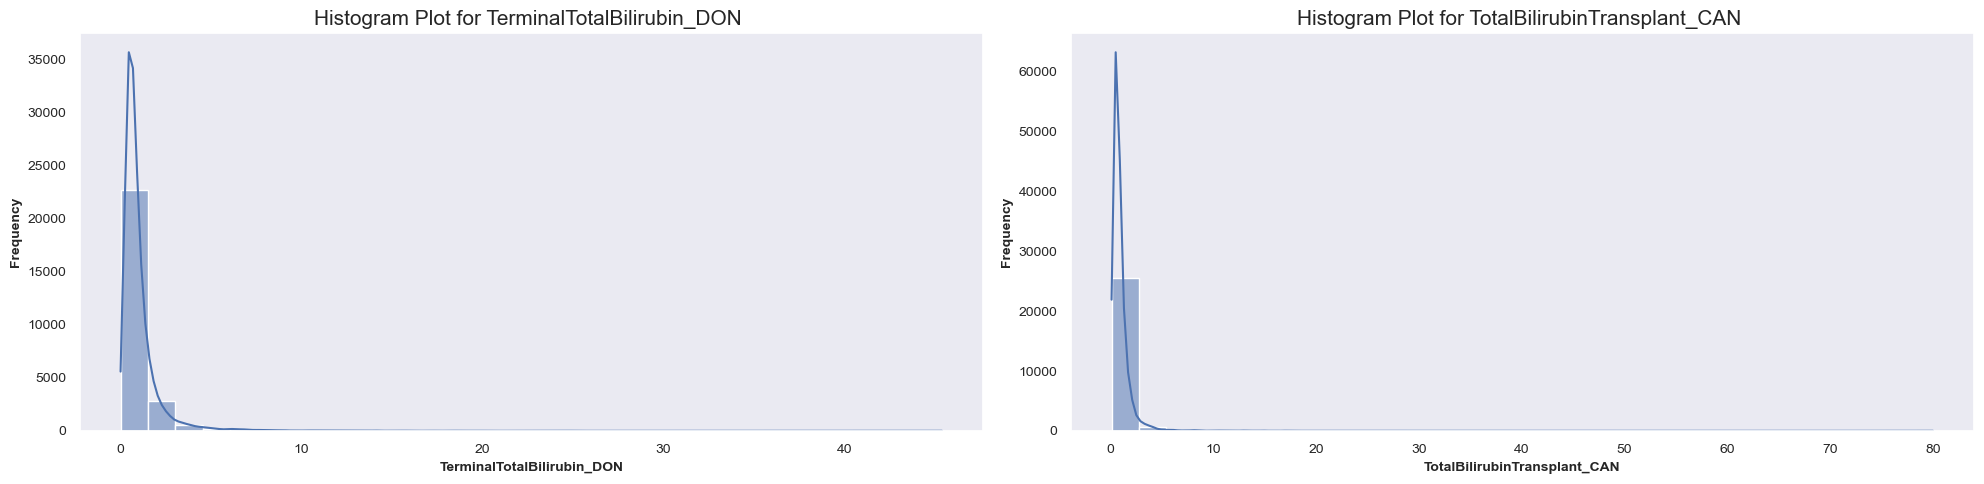

In [32]:
uv.histogramPlot(df_impute, features, bins=30)

In [33]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: 0.0298
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


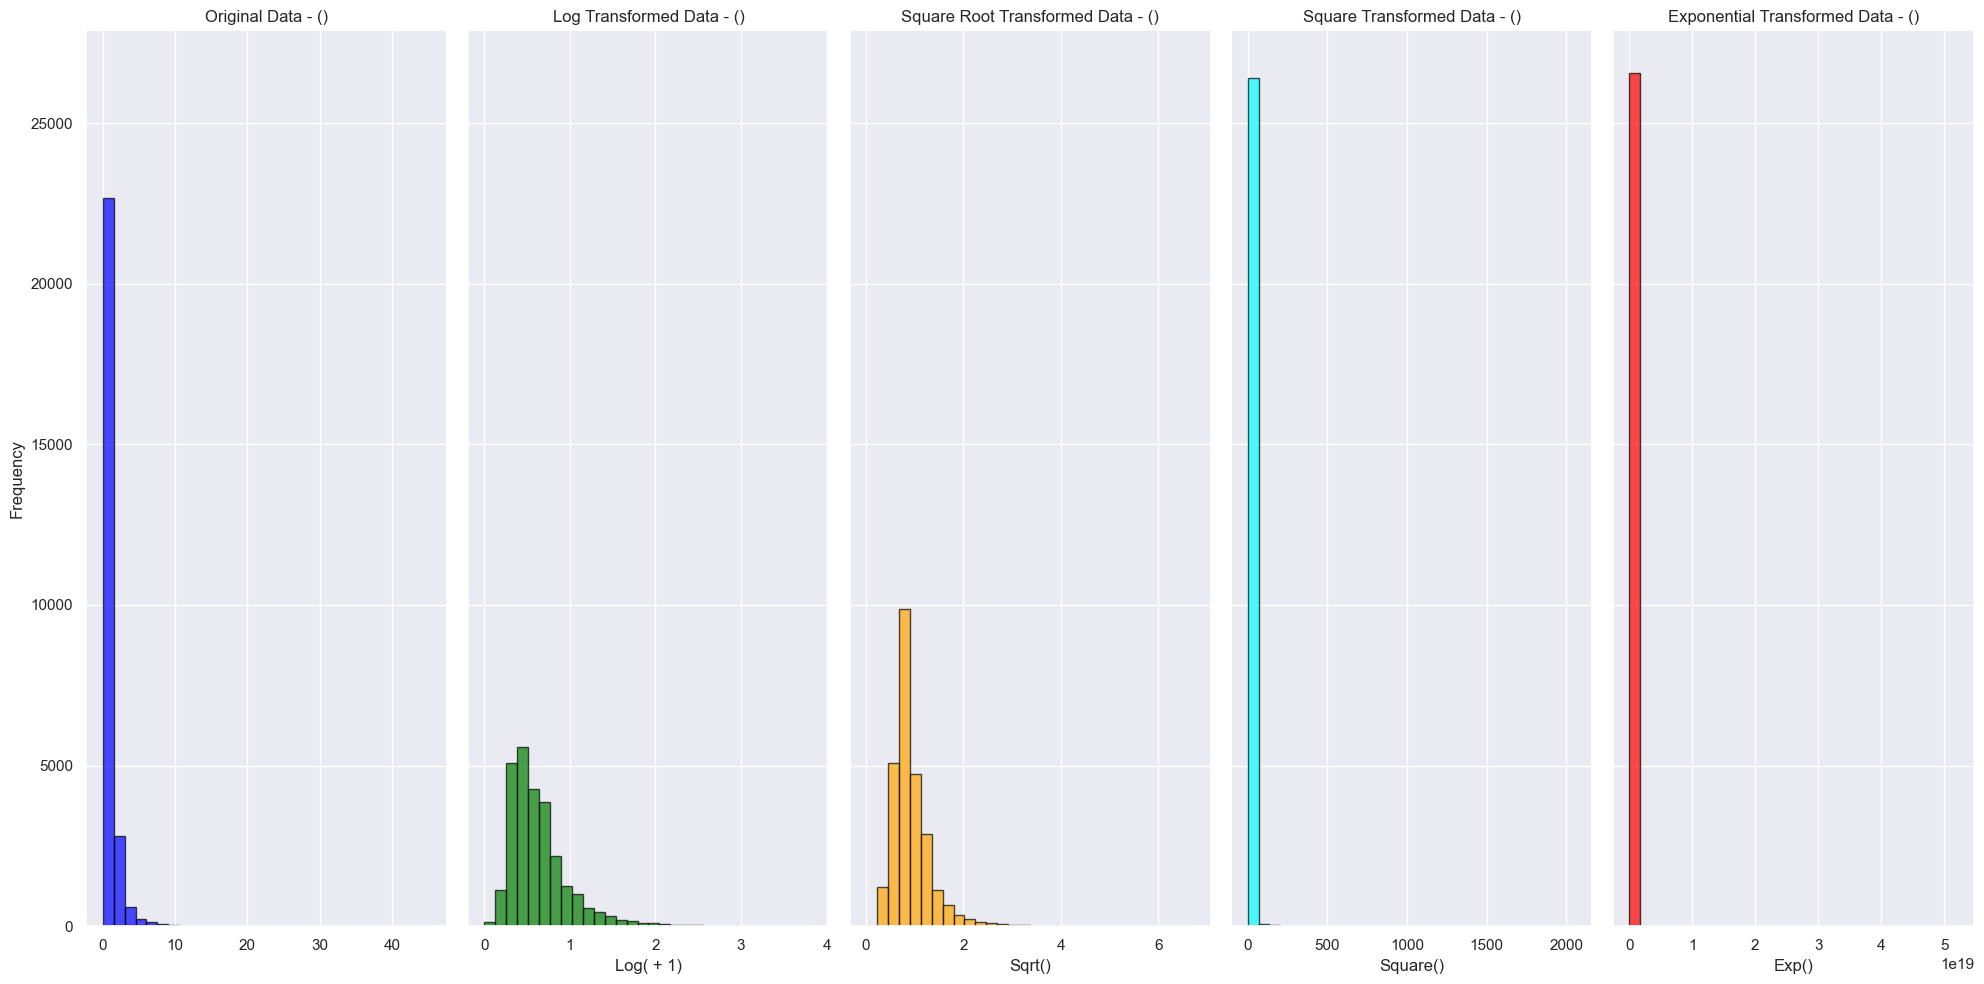

In [34]:
uv.transformPlots(df_impute['TerminalTotalBilirubin_DON'], bins=30)

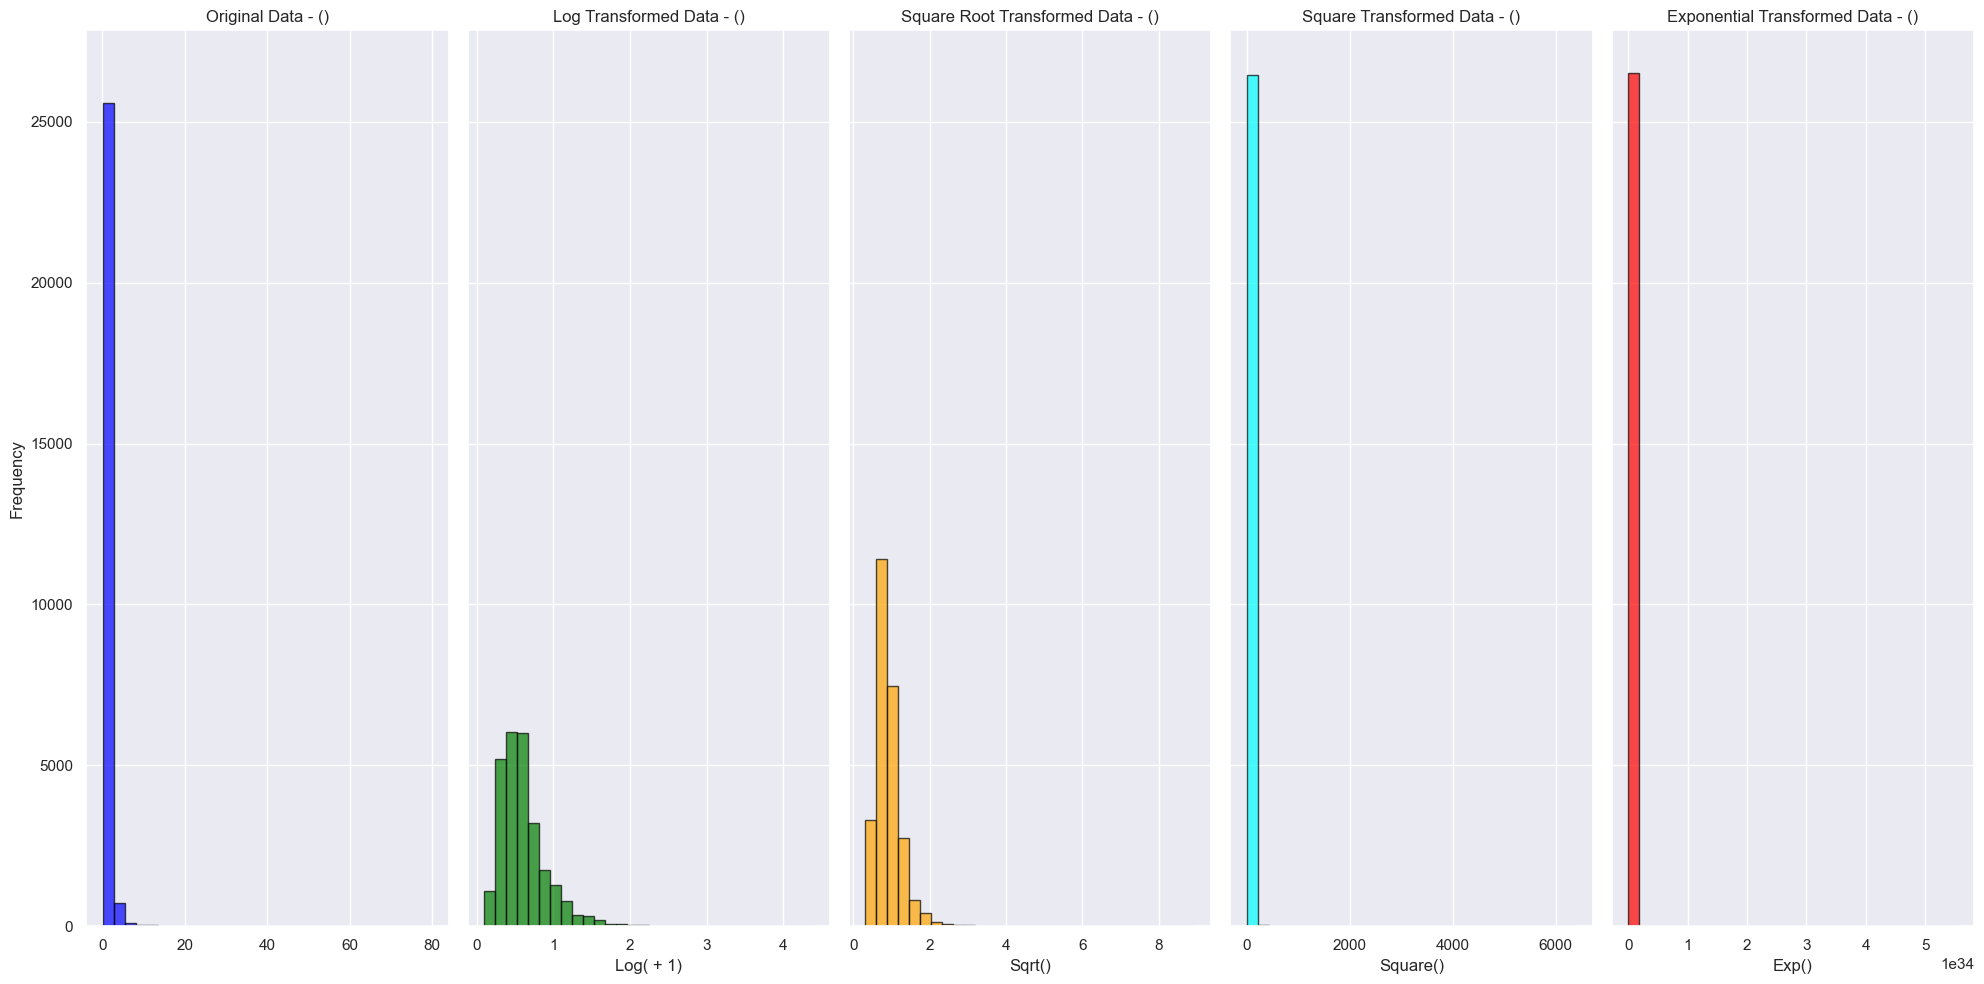

In [35]:
uv.transformPlots(df_impute['TotalBilirubinTransplant_CAN'], bins=30)

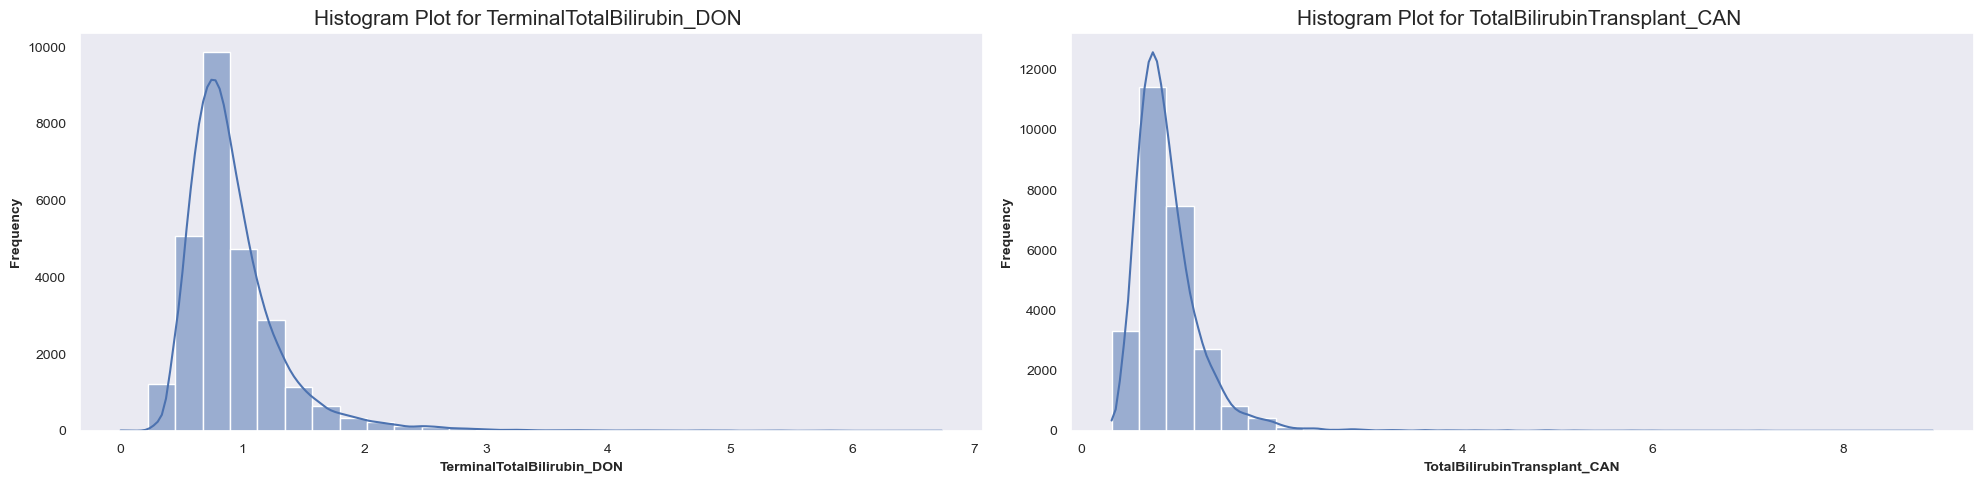

In [36]:
# transform
df_impute[features] = np.sqrt(df_impute[features])
# plot
uv.histogramPlot(df_impute, features, bins=30)

In [37]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: 0.0512
Fail to reject null hypothesis: Data may be Missing Completely At Random (MCAR).


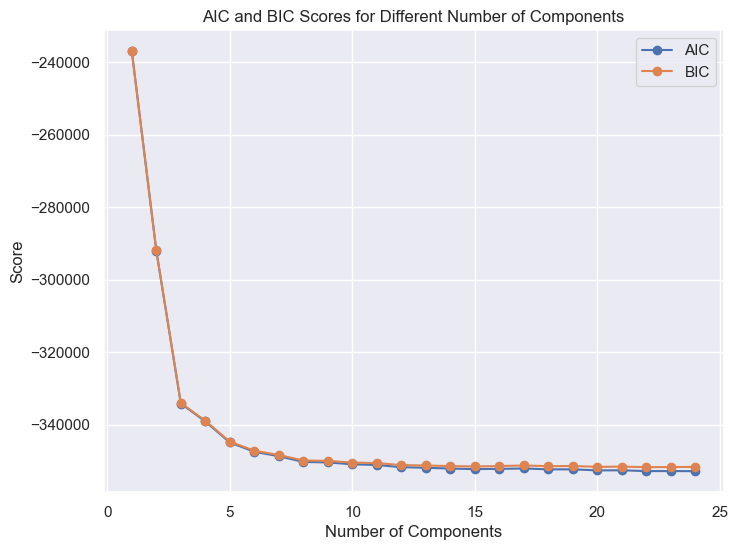

Optimal number of components: 22


In [38]:
# find components
ui.findGaussianMixtureComponents(df[features], component_range=range(1, 25), seed=RANDOM_STATE)

In [39]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=22)

The best n_neighbors for KNN imputer is: 2
The best weights for KNN imputer is: distance


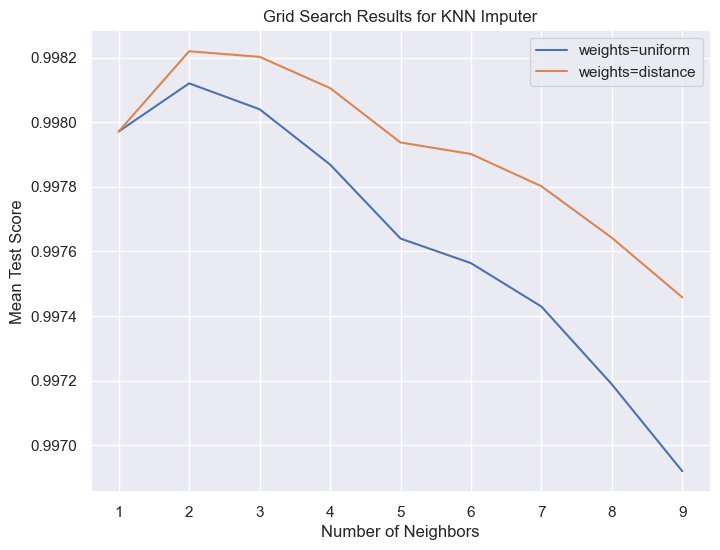

In [40]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [41]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
TerminalTotalBilirubin_DON,26600.0,0.932899,0.417249,0.000000,0.707107,0.83666,1.048809,6.737952
TotalBilirubinTransplant_CAN,26600.0,0.909402,0.400213,0.316228,0.707107,0.83666,1.048809,8.944272


In [42]:
# new feature
df_impute['TotalBilirubin_Difference'] = df_impute.TotalBilirubinTransplant_CAN - df_impute.TerminalTotalBilirubin_DON
df_impute['TotalBilirubin_Addition'] = df_impute.TotalBilirubinTransplant_CAN + df_impute.TerminalTotalBilirubin_DON
# display
features = uf.getFeatureList(df_impute, 'Bilirubin')

                                count      mean       std       min       25%       50%       75%       max
TerminalTotalBilirubin_DON    26600.0  0.932899  0.417249  0.000000  0.707107  0.836660  1.048809  6.737952
TotalBilirubinTransplant_CAN  26600.0  0.909402  0.400213  0.316228  0.707107  0.836660  1.048809  8.944272
TotalBilirubin_Addition       26600.0  1.842301  0.580766  0.547723  1.481703  1.730939  2.061405  9.491994
TotalBilirubin_Difference     26600.0 -0.023498  0.575539 -5.901292 -0.276062  0.000000  0.245748  8.396549

:::: NaN Count:
TerminalTotalBilirubin_DON      0
TotalBilirubinTransplant_CAN    0
TotalBilirubin_Addition         0
TotalBilirubin_Difference       0


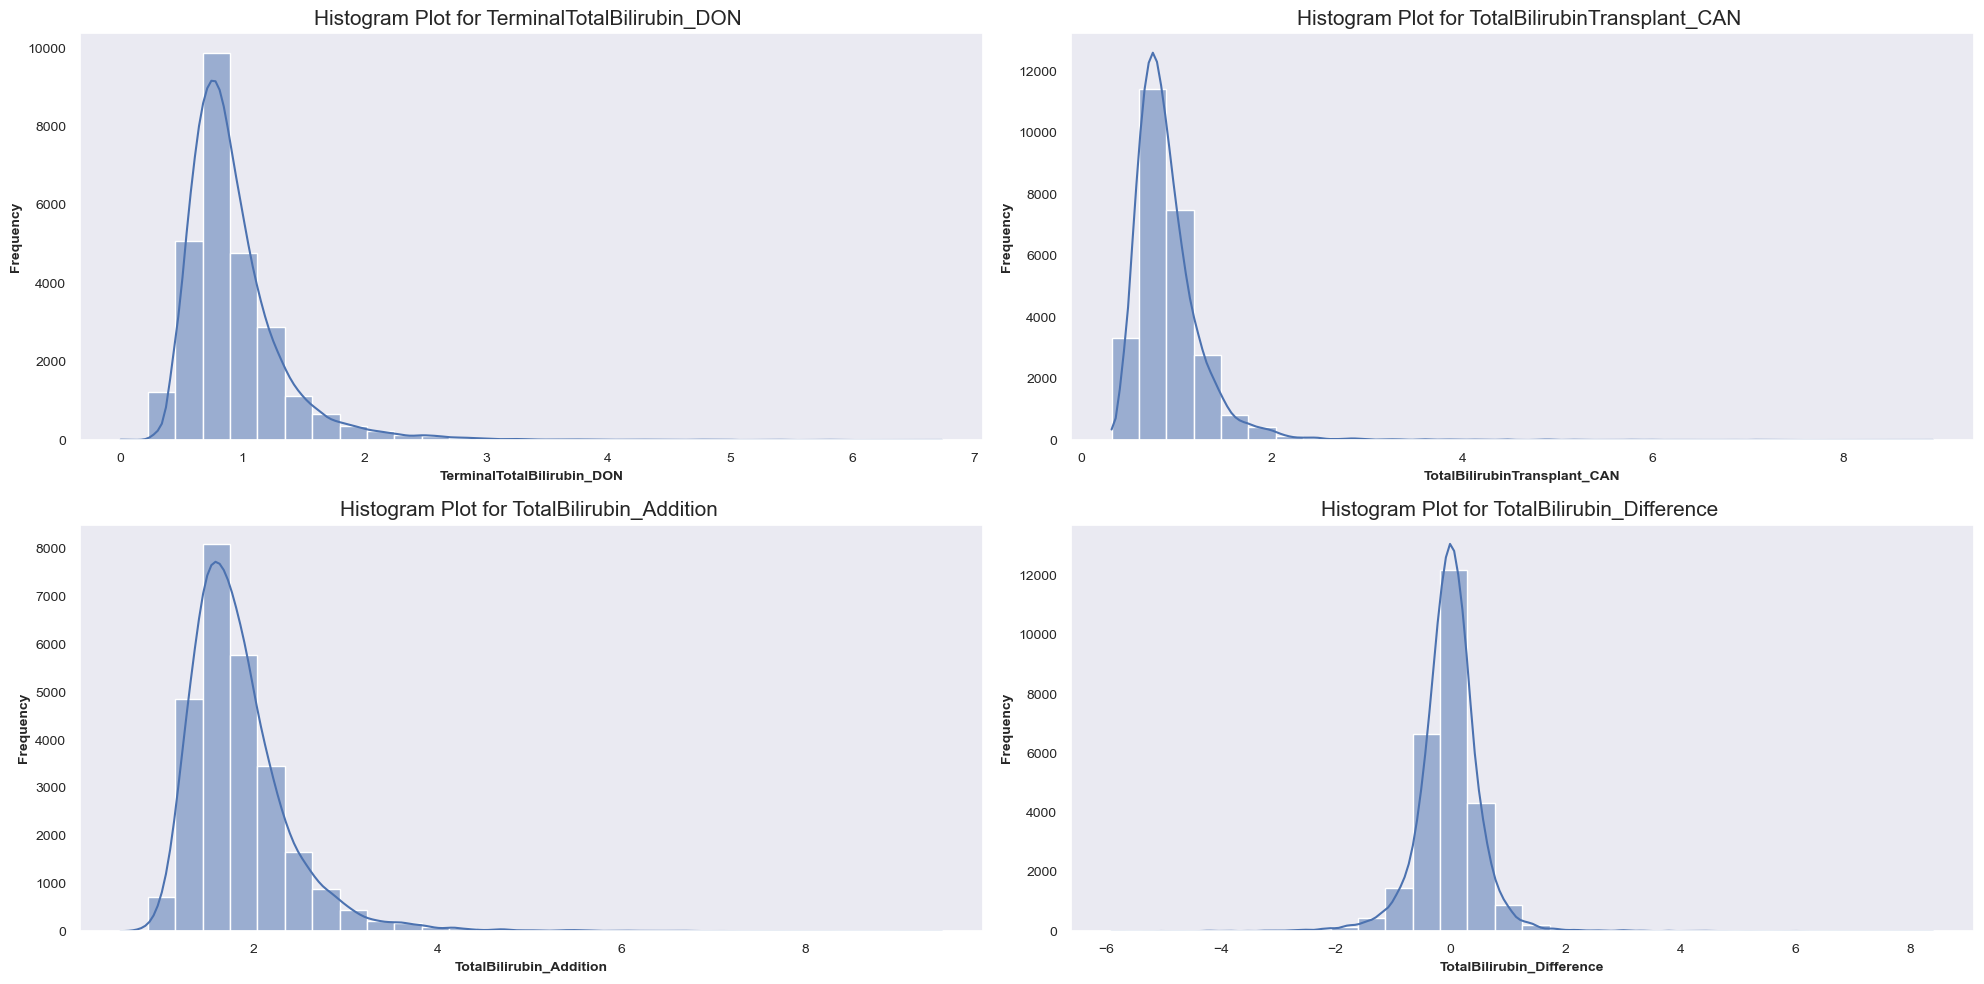

In [43]:
uv.histogramPlot(df_impute, features, bins=30)

#### OrganRecovery

In [44]:
features = uf.getFeatureList(df_impute, 'OrganRecovery')

                          count       mean       std   min   25%   50%   75%    max
OrganRecovery_PCO2_DON  26531.0  38.640024  7.026554  10.1  34.0  38.0  42.1  116.3

:::: NaN Count:
OrganRecovery_PCO2_DON    69


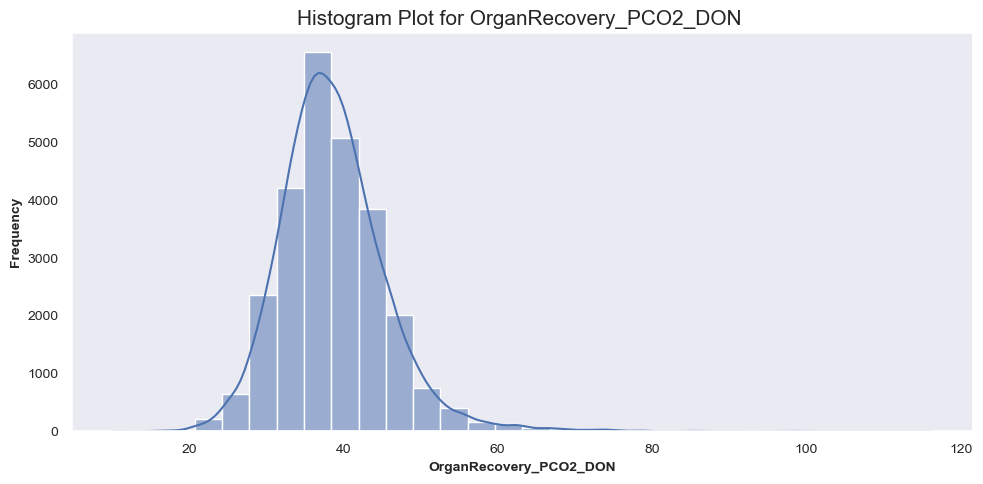

In [45]:
uv.histogramPlot(df_impute, features, bins=30)

In [46]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


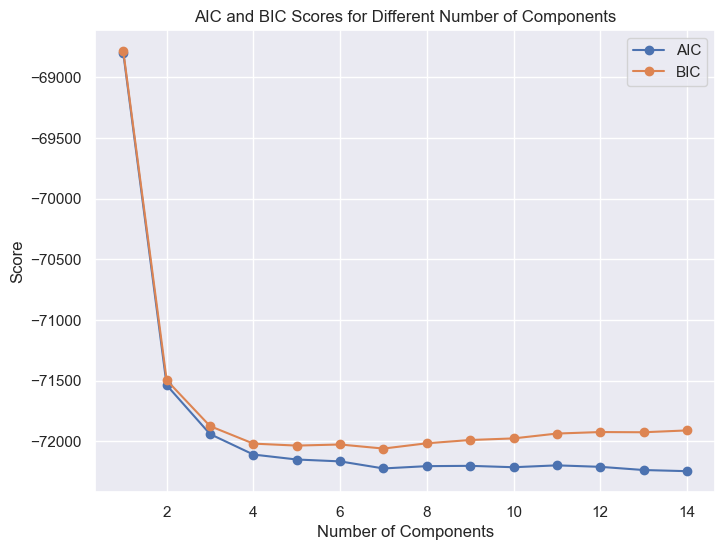

Optimal number of components: 7


In [47]:
# find components
ui.findGaussianMixtureComponents(df[features], component_range=range(1, 15), seed=RANDOM_STATE)

In [48]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=7)

The best n_neighbors for KNN imputer is: 2
The best weights for KNN imputer is: distance


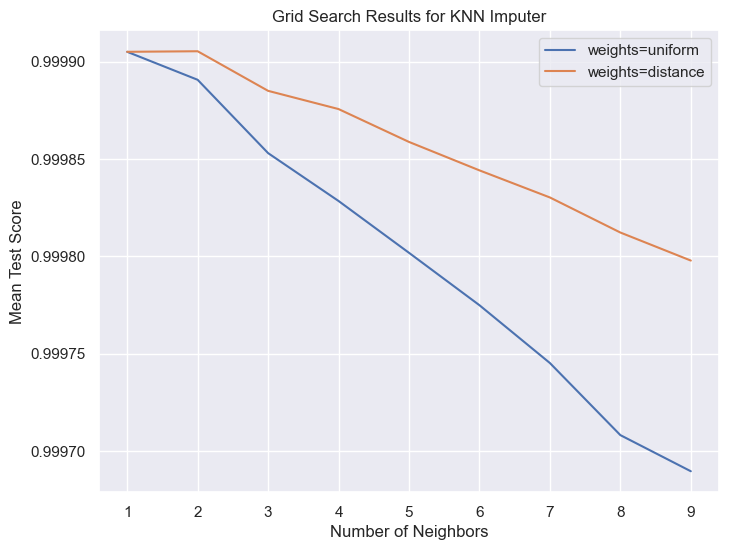

In [49]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [50]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
OrganRecovery_PCO2_DON,26600.0,38.639072,7.01932,10.1,34.0,38.0,42.1,116.3


#### BloodPH

In [51]:
features = uf.getFeatureList(df_impute, 'BloodPH')

               count      mean       std  min   25%   50%   75%   max
BloodPH_DON  26537.0  7.416184  0.071712  5.0  7.38  7.42  7.46  7.93

:::: NaN Count:
BloodPH_DON    63


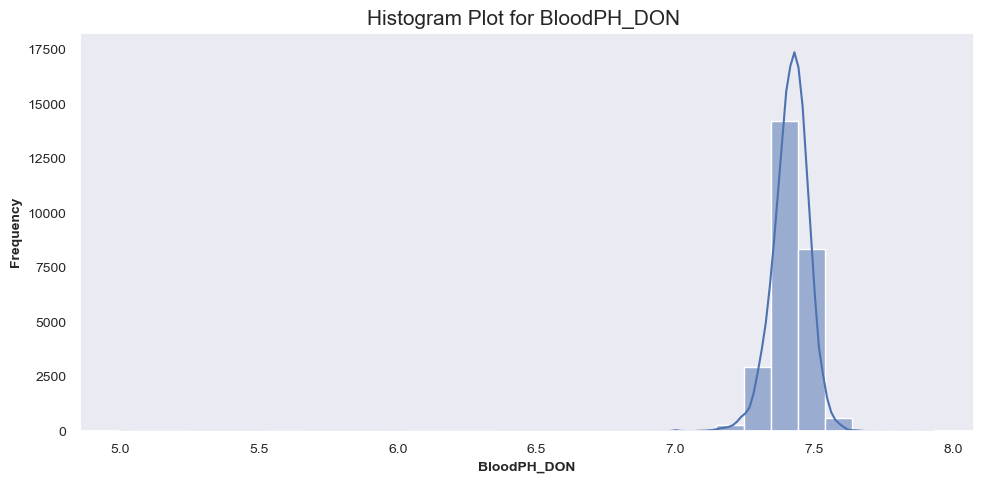

In [52]:
uv.histogramPlot(df_impute, features, bins=30)

In [53]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


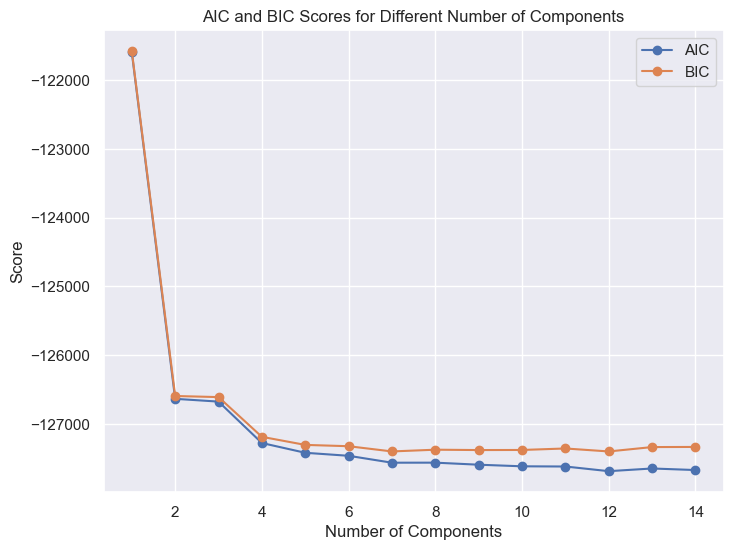

Optimal number of components: 12


In [54]:
# find components
ui.findGaussianMixtureComponents(df[features], component_range=range(1, 15), seed=RANDOM_STATE)

In [55]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=12)

The best n_neighbors for KNN imputer is: 1
The best weights for KNN imputer is: uniform


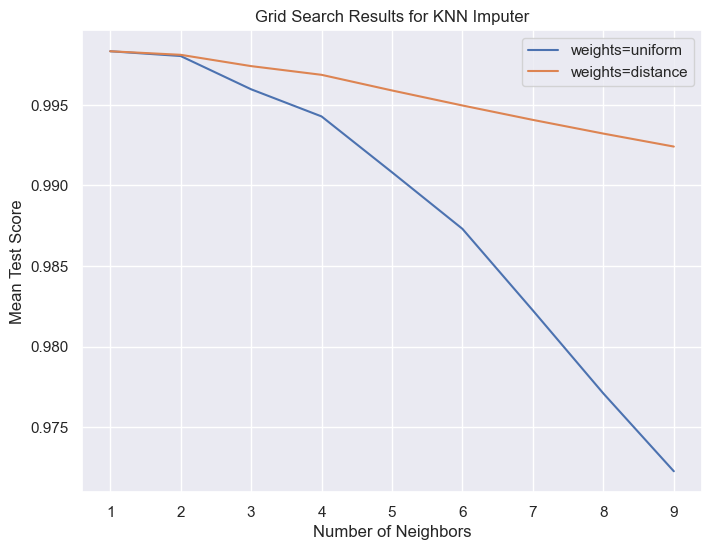

In [56]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [57]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
BloodPH_DON,26600.0,7.416174,0.071649,5.0,7.38,7.42,7.46,7.93


#### Level_SGOT

In [58]:
features = uf.getFeatureList(df_impute, 'Level_SGOT_ALT|Level_SGOT_AST')

                      count        mean         std  min   25%   50%   75%      max
Level_SGOT_ALT_DON  26556.0  114.537393  410.851176  3.0  23.0  41.0  83.0  44117.0
Level_SGOT_AST_DON  26556.0  101.949910  302.800755  0.3  26.0  44.0  87.0  10254.0

:::: NaN Count:
Level_SGOT_ALT_DON    44
Level_SGOT_AST_DON    44


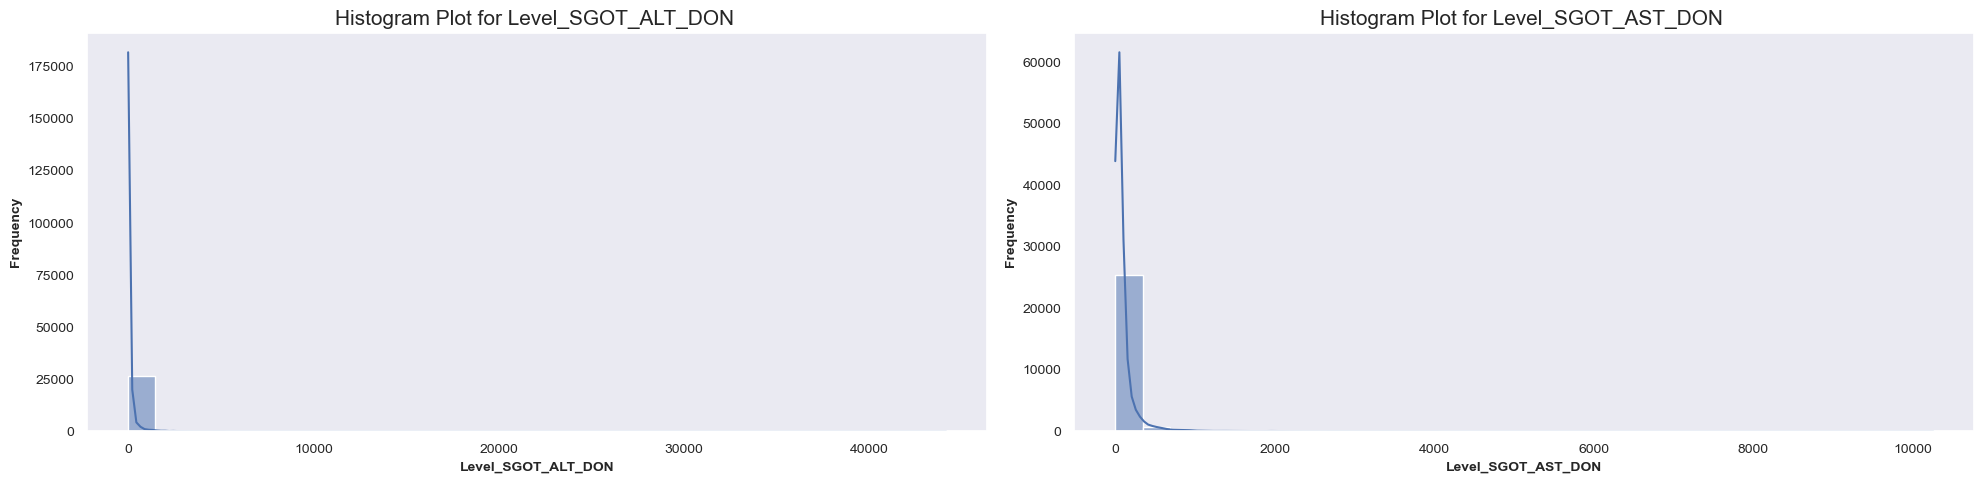

In [59]:
uv.histogramPlot(df_impute, features, bins=30)

<Axes: >

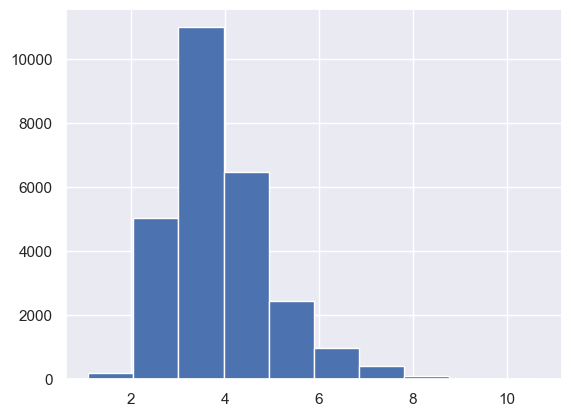

In [60]:
np.log(df_impute.Level_SGOT_ALT_DON).hist()

<Axes: >

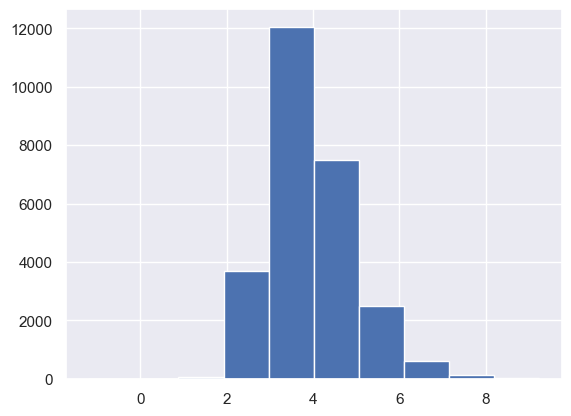

In [61]:
np.log(df_impute.Level_SGOT_AST_DON).hist()

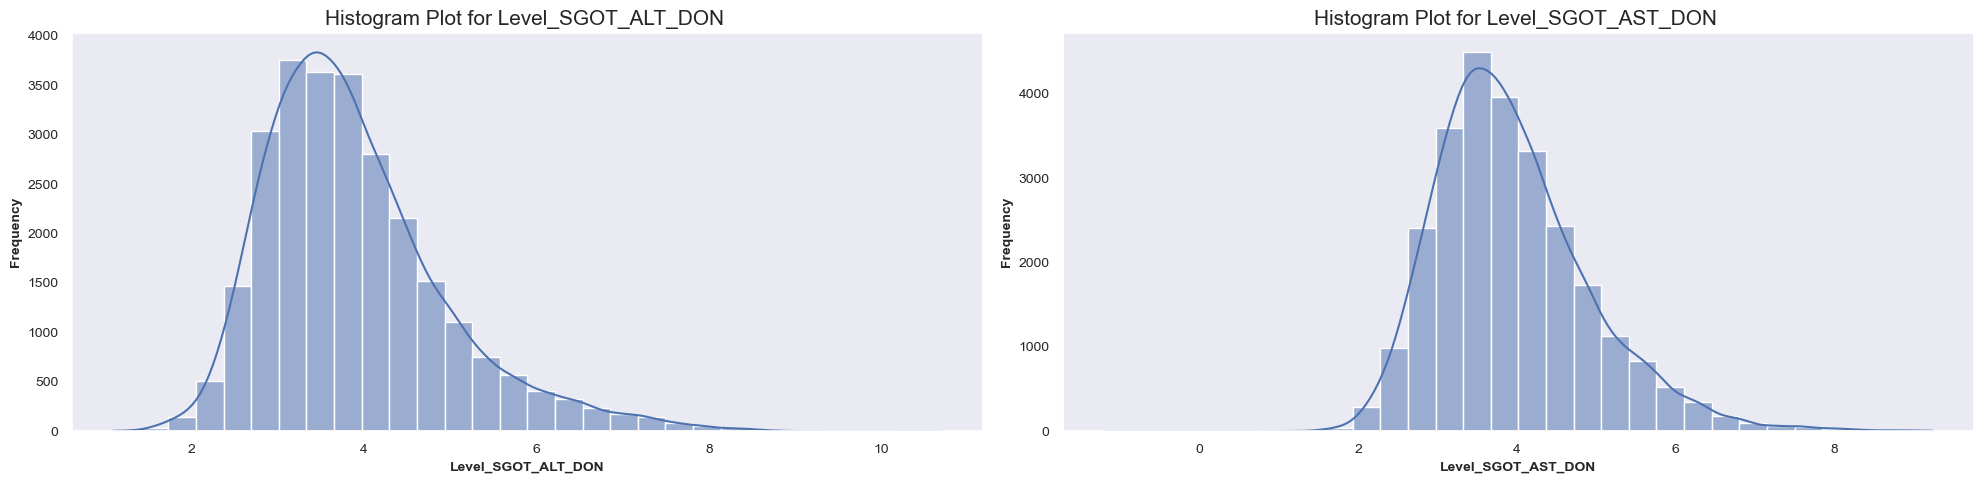

In [62]:
# transform
df_impute[features] = np.log(df_impute[features])
# plot
uv.histogramPlot(df_impute, features, bins=30)

In [63]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


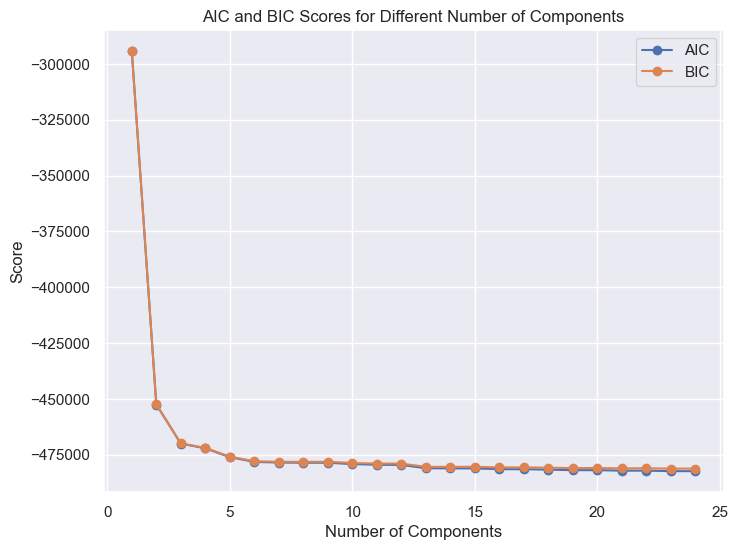

Optimal number of components: 23


In [64]:
# find components
ui.findGaussianMixtureComponents(df[features], component_range=range(1, 25), seed=RANDOM_STATE)

In [65]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=23)

The best n_neighbors for KNN imputer is: 3
The best weights for KNN imputer is: distance


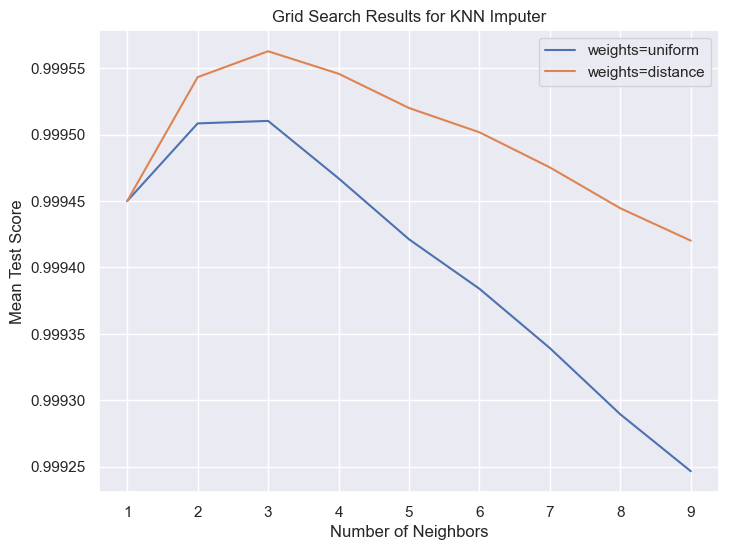

In [66]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [67]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Level_SGOT_ALT_DON,26600.0,3.893777,1.064142,1.098612,3.135494,3.713572,4.418841,10.694600
Level_SGOT_AST_DON,26600.0,3.935079,0.978899,-1.203973,3.258097,3.784190,4.465908,9.235423


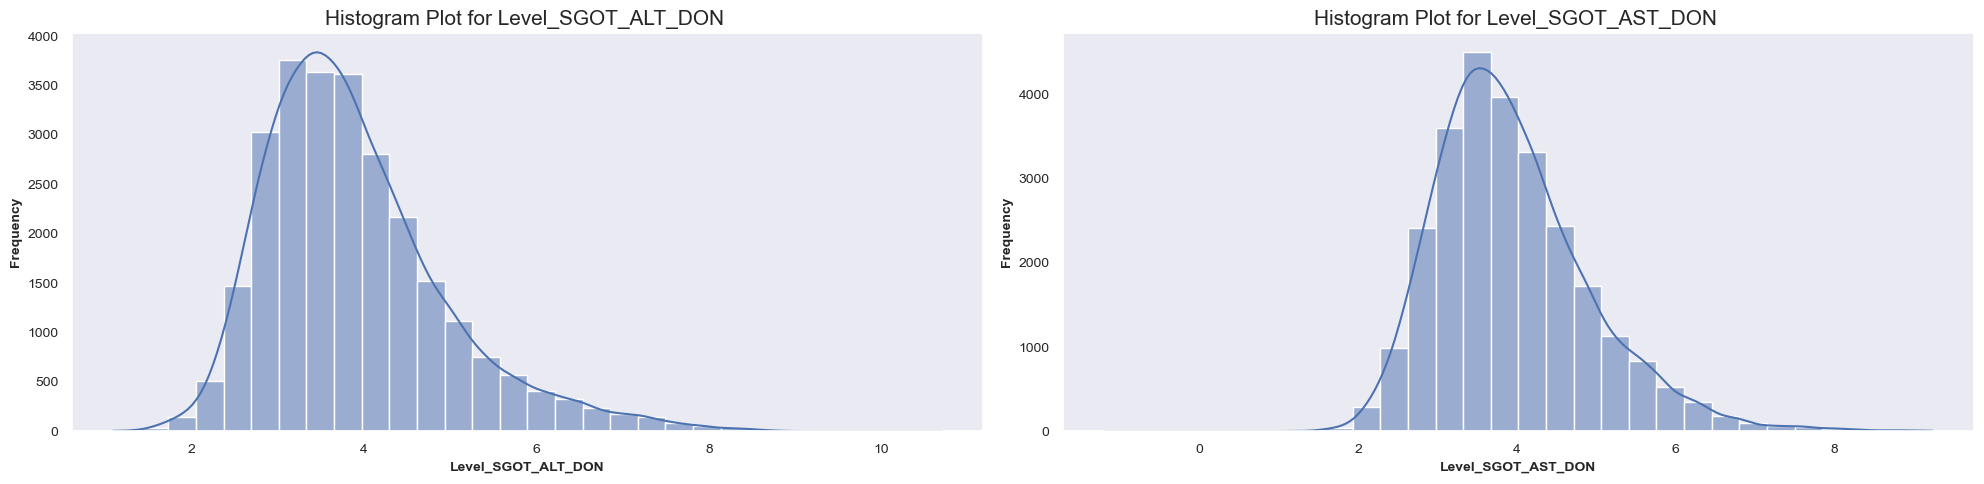

In [68]:
uv.histogramPlot(df_impute, features, bins=30)

In [69]:
# re-calc feature
df_impute['Level_SGOT_Difference_DON'] = df_impute.Level_SGOT_ALT_DON - df_impute.Level_SGOT_AST_DON
df_impute['Level_SGOT_Addition_DON'] = df_impute.Level_SGOT_ALT_DON + df_impute.Level_SGOT_AST_DON
# display
features = uf.getFeatureList(df_impute, 'Level_SGOT')

                             count      mean       std       min       25%       50%       75%        max
Level_SGOT_ALT_DON         26600.0  3.893777  1.064142  1.098612  3.135494  3.713572  4.418841  10.694600
Level_SGOT_AST_DON         26600.0  3.935079  0.978899 -1.203973  3.258097  3.784190  4.465908   9.235423
Level_SGOT_Addition_DON    26600.0  7.828856  1.893895  1.648659  6.527958  7.533426  8.787526  18.308192
Level_SGOT_Difference_DON  26600.0 -0.041302  0.771005 -4.926674 -0.536801 -0.077231  0.417735   5.683965

:::: NaN Count:
Level_SGOT_ALT_DON           0
Level_SGOT_AST_DON           0
Level_SGOT_Addition_DON      0
Level_SGOT_Difference_DON    0


#### Creatinine

In [70]:
features = uf.getFeatureList(df_impute, 'CreatinineRegistration|CreatinineTransplant')

                              count      mean       std   min   25%  50%  75%   max
CreatinineRegistration_CAN  26579.0  1.362137  0.953078  0.08  0.94  1.2  1.5  24.0
CreatinineTransplant_CAN    26579.0  1.371054  0.997589  0.06  0.94  1.2  1.5  37.0

:::: NaN Count:
CreatinineRegistration_CAN    21
CreatinineTransplant_CAN      21


In [71]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


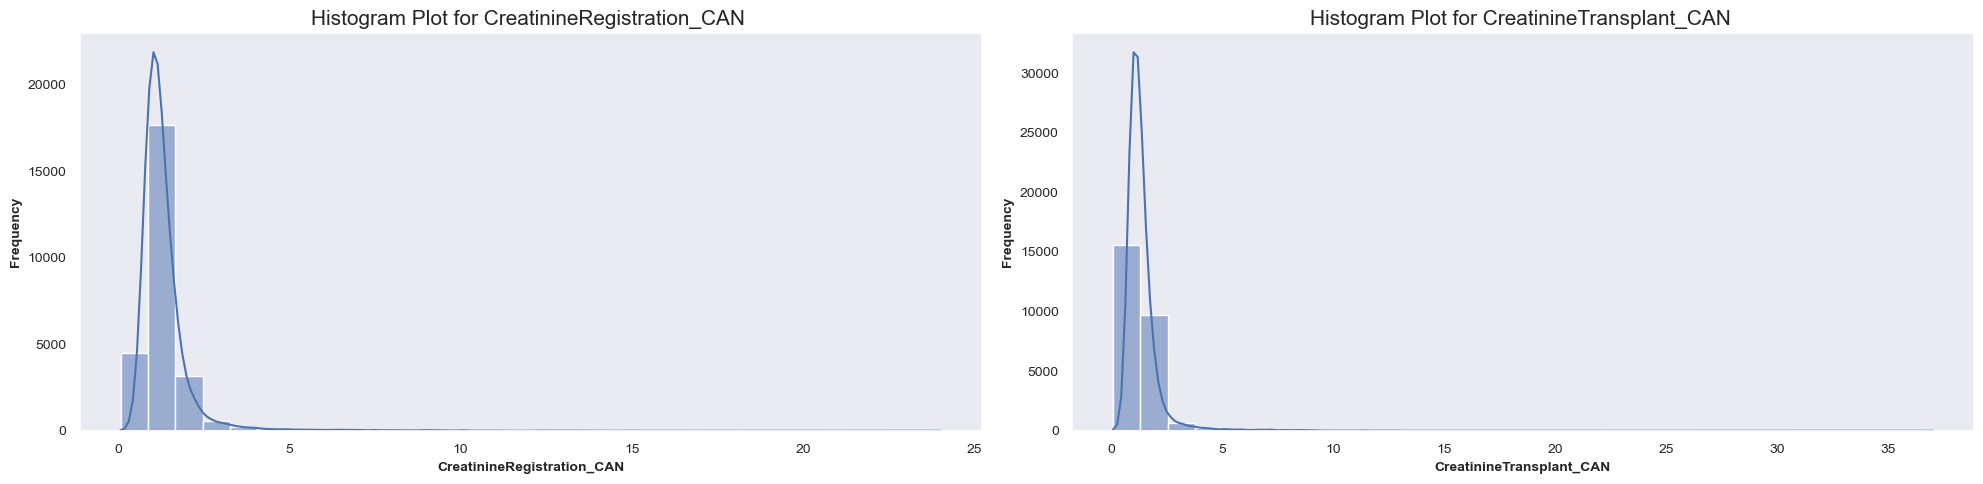

In [72]:
uv.histogramPlot(df_impute, features, bins=30)

<Axes: >

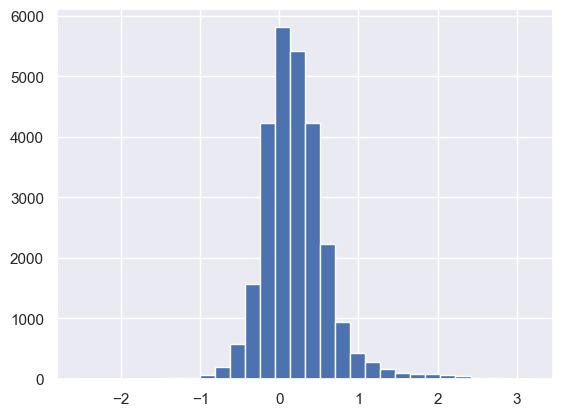

In [73]:
np.log(df_impute.CreatinineRegistration_CAN).hist(bins=30)

<Axes: >

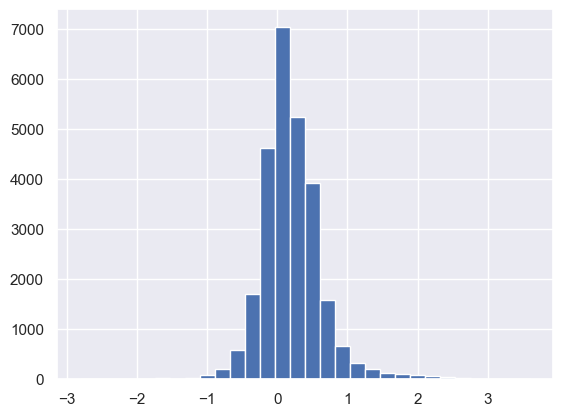

In [74]:
np.log(df_impute.CreatinineTransplant_CAN).hist(bins=30)

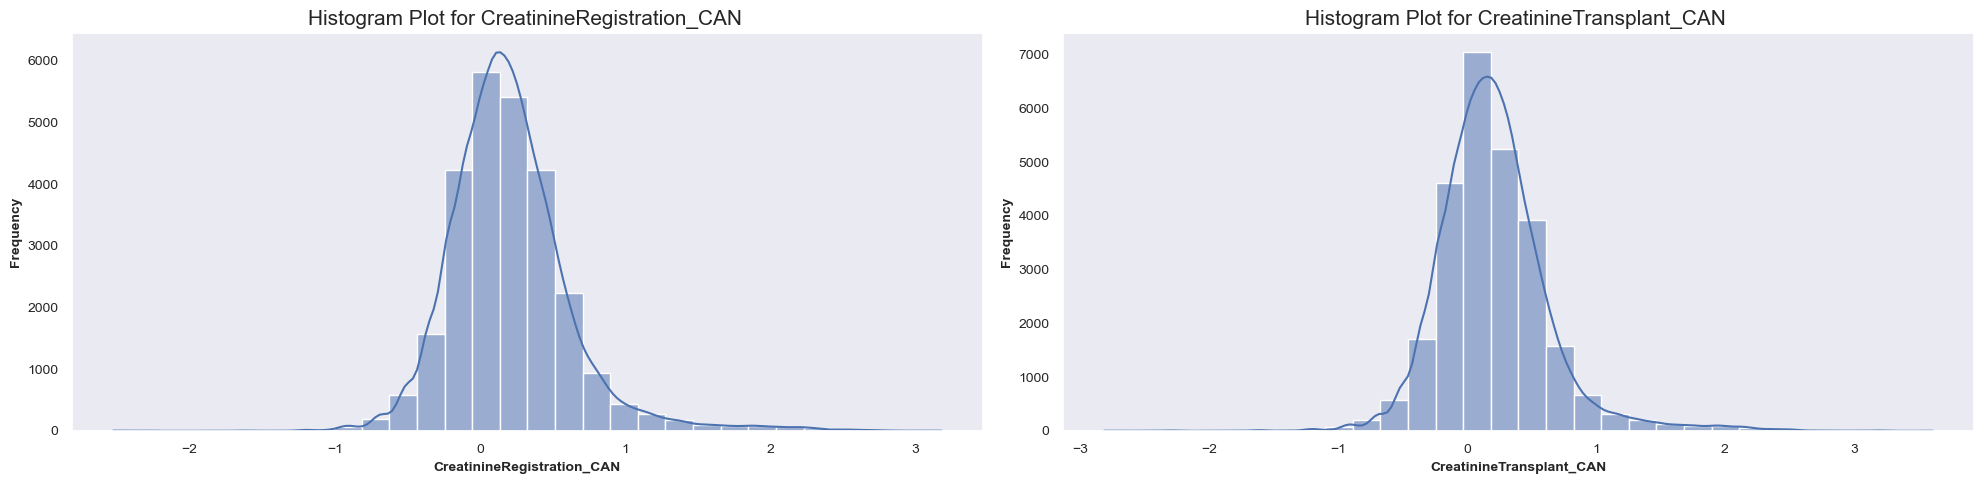

In [75]:
# transform
df_impute[features] = np.log(df_impute[features])
# plot
uv.histogramPlot(df_impute, features, bins=30)

In [76]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


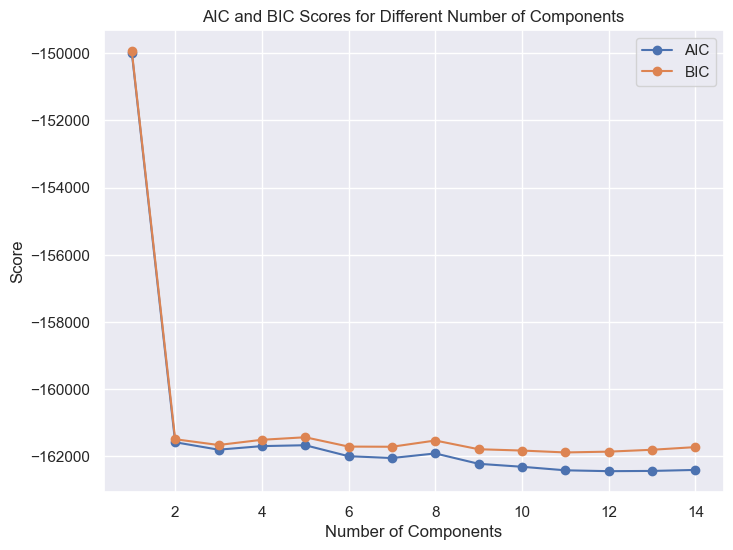

Optimal number of components: 11


In [77]:
# find components
ui.findGaussianMixtureComponents(df_impute[features], component_range=range(1, 15), seed=RANDOM_STATE)

In [78]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=11)

The best n_neighbors for KNN imputer is: 3
The best weights for KNN imputer is: distance


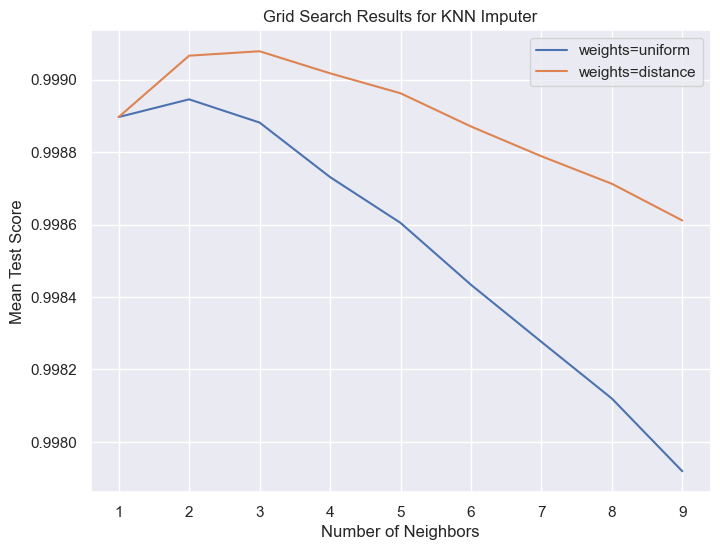

In [79]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [80]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
CreatinineRegistration_CAN,26600.0,0.199890,0.416614,-2.525729,-0.061875,0.182322,0.405465,3.178054
CreatinineTransplant_CAN,26600.0,0.202351,0.425841,-2.813411,-0.061875,0.182322,0.405465,3.610918


In [81]:
# re-calc feature
df_impute['Creatinine_Difference_CAN'] =  df_impute.CreatinineRegistration_CAN - df_impute.CreatinineTransplant_CAN
df_impute['Creatinine_Addition_CAN'] =  df_impute.CreatinineRegistration_CAN + df_impute.CreatinineTransplant_CAN
df_impute['Creatinine_Mean_CAN'] =  (df_impute.CreatinineRegistration_CAN + df_impute.CreatinineTransplant_CAN) / 2
# display
features = uf.getFeatureList(df_impute, 'Creatinine')

                              count      mean       std       min       25%           50%       75%        max
CreatinineRegistration_CAN  26600.0  0.199890  0.416614 -2.525729 -0.061875  1.823216e-01  0.405465   3.178054
CreatinineTransplant_CAN    26600.0  0.202351  0.425841 -2.813411 -0.061875  1.823216e-01  0.405465   3.610918
Creatinine_Addition_CAN     26600.0  0.402241  0.775449 -3.526761 -0.079043  3.541718e-01  0.767489   6.400922
Creatinine_DON              26560.0  1.503744  1.556497  0.040000  0.760000  1.000000e+00  1.490000  23.000000
Creatinine_Difference_CAN   26600.0 -0.002460  0.329386 -3.608837 -0.158422 -1.110223e-16  0.150282   3.705409
Creatinine_Mean_CAN         26600.0  0.201120  0.387724 -1.763380 -0.039522  1.770859e-01  0.383745   3.200461

:::: NaN Count:
CreatinineRegistration_CAN     0
CreatinineTransplant_CAN       0
Creatinine_Addition_CAN        0
Creatinine_DON                40
Creatinine_Difference_CAN      0
Creatinine_Mean_CAN            0


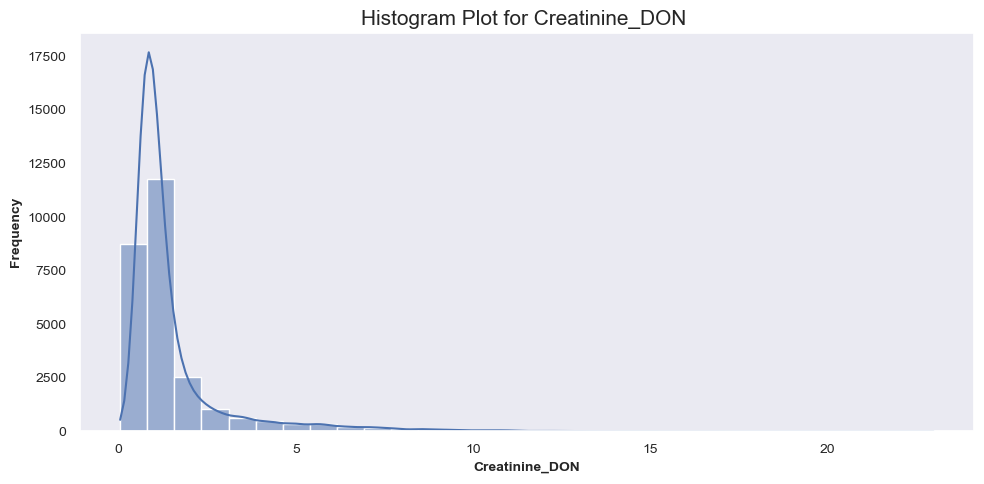

In [82]:
# initialize list
features = ['Creatinine_DON']
uv.histogramPlot(df_impute, features, bins=30)

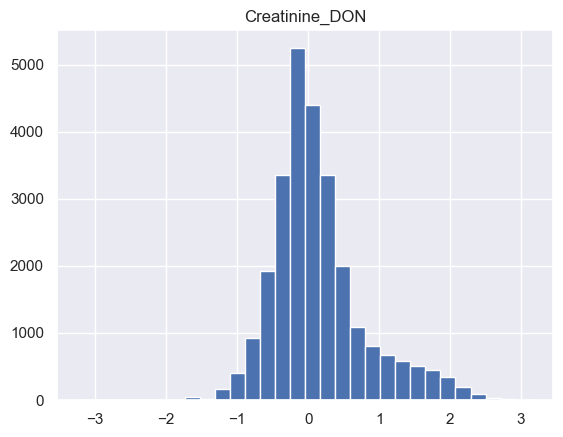

In [83]:
np.log(df_impute[features]).hist(bins=30);

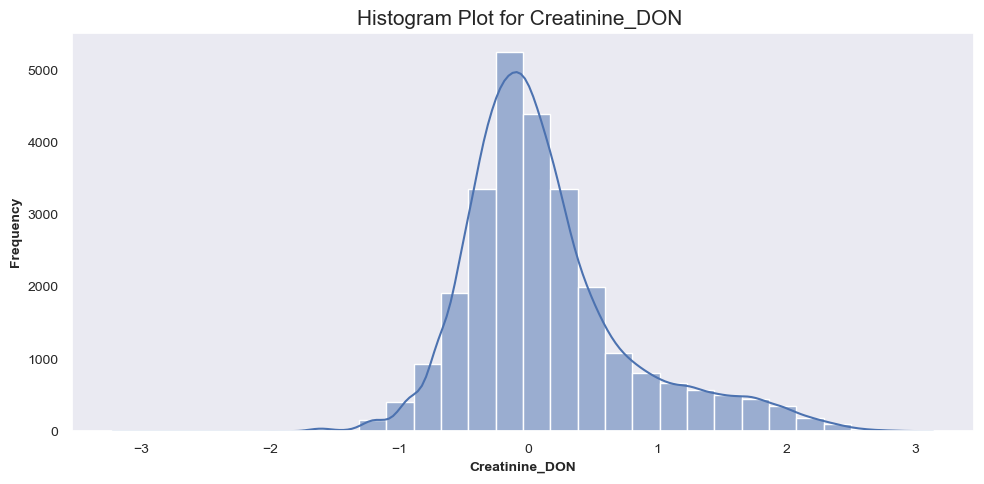

In [84]:
# transform
df_impute[features] = np.log(df_impute[features])
# plot
uv.histogramPlot(df_impute, features, bins=30)

In [85]:
# stats test
usf.testMCAR(pd.DataFrame(df_impute[features]))

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


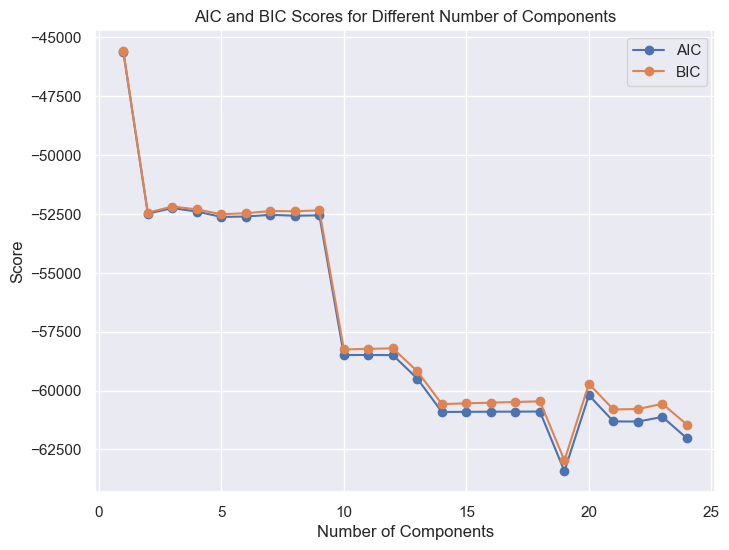

Optimal number of components: 19


In [86]:
# find components
ui.findGaussianMixtureComponents(pd.DataFrame(df_impute[features]), component_range=range(1, 25), seed=RANDOM_STATE)

In [87]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=19)

The best n_neighbors for KNN imputer is: 1
The best weights for KNN imputer is: uniform


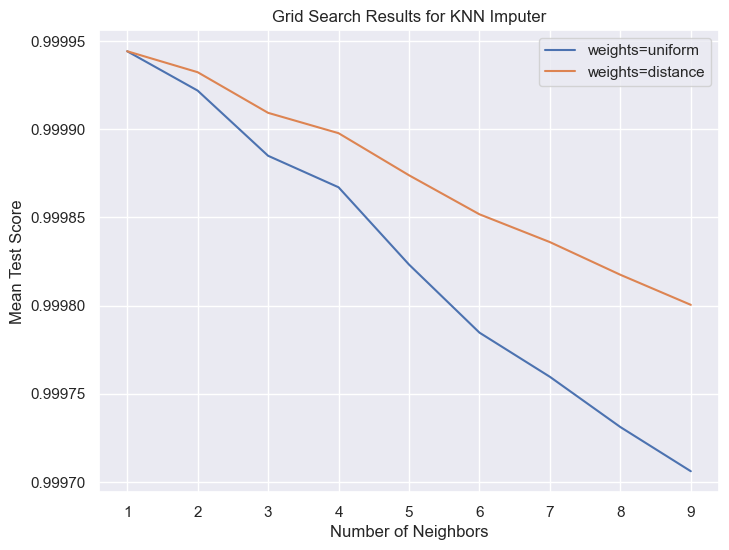

In [88]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [89]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Creatinine_DON,26600.0,0.137157,0.651232,-3.218876,-0.274437,0.0,0.398776,3.135494


In [90]:
features = uf.getFeatureList(df_impute, 'Creatinine')

                              count      mean       std       min       25%           50%       75%       max
CreatinineRegistration_CAN  26600.0  0.199890  0.416614 -2.525729 -0.061875  1.823216e-01  0.405465  3.178054
CreatinineTransplant_CAN    26600.0  0.202351  0.425841 -2.813411 -0.061875  1.823216e-01  0.405465  3.610918
Creatinine_Addition_CAN     26600.0  0.402241  0.775449 -3.526761 -0.079043  3.541718e-01  0.767489  6.400922
Creatinine_DON              26600.0  0.137157  0.651232 -3.218876 -0.274437  0.000000e+00  0.398776  3.135494
Creatinine_Difference_CAN   26600.0 -0.002460  0.329386 -3.608837 -0.158422 -1.110223e-16  0.150282  3.705409
Creatinine_Mean_CAN         26600.0  0.201120  0.387724 -1.763380 -0.039522  1.770859e-01  0.383745  3.200461

:::: NaN Count:
CreatinineRegistration_CAN    0
CreatinineTransplant_CAN      0
Creatinine_Addition_CAN       0
Creatinine_DON                0
Creatinine_Difference_CAN     0
Creatinine_Mean_CAN           0


#### BloodUreaNitrogenLevel

In [91]:
features = uf.getFeatureList(df_impute, 'BloodUreaNitrogenLevel')

                              count       mean        std  min   25%   50%   75%    max
BloodUreaNitrogenLevel_DON  26560.0  24.173811  19.996607  0.5  12.0  18.0  29.0  250.0

:::: NaN Count:
BloodUreaNitrogenLevel_DON    40


In [92]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


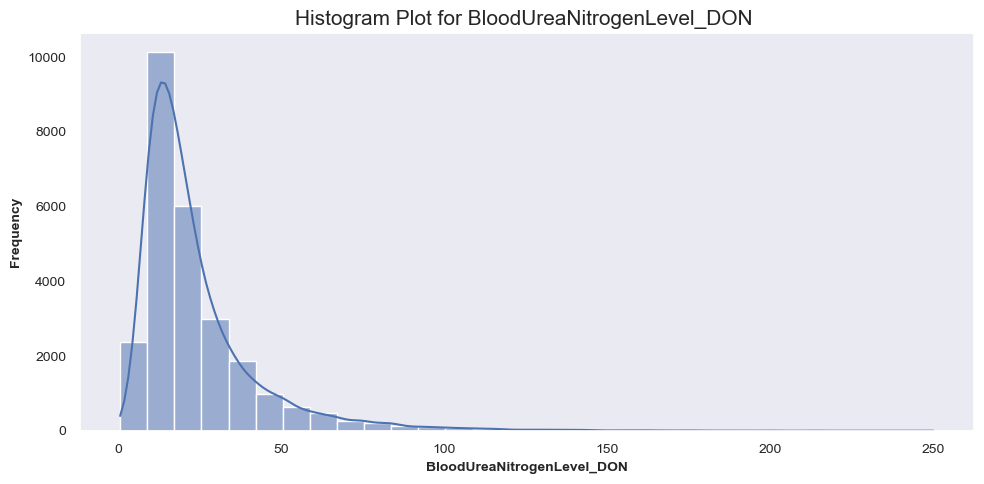

In [93]:
uv.histogramPlot(df_impute, features, bins=30)

In [94]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


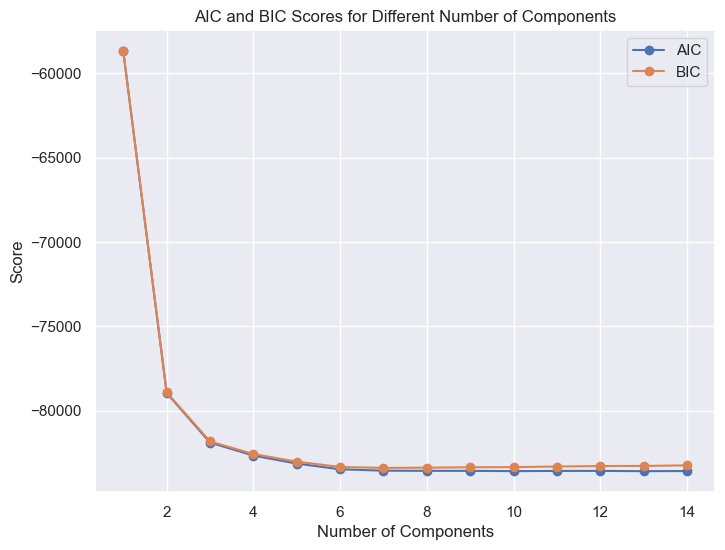

Optimal number of components: 7


In [95]:
# find components
ui.findGaussianMixtureComponents(df_impute[features], component_range=range(1, 15), seed=RANDOM_STATE)

In [96]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=7)

The best n_neighbors for KNN imputer is: 1
The best weights for KNN imputer is: uniform


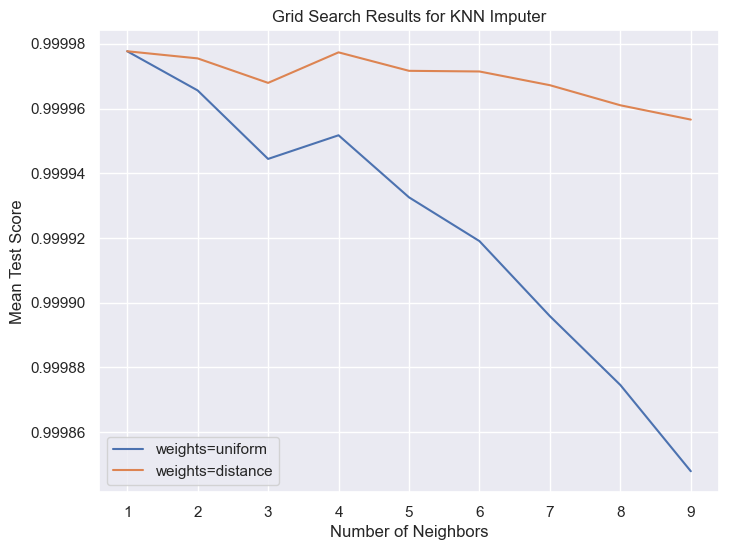

In [97]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [98]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
BloodUreaNitrogenLevel_DON,26600.0,24.170945,19.98396,0.5,12.0,18.0,29.0,250.0


#### Hematocrit

In [99]:
features = uf.getFeatureList(df_impute, 'Hematocrit')

                  count       mean       std  min   25%   50%   75%   max
Hematocrit_DON  26560.0  28.404058  5.006004  2.3  25.0  27.9  31.3  75.0

:::: NaN Count:
Hematocrit_DON    40


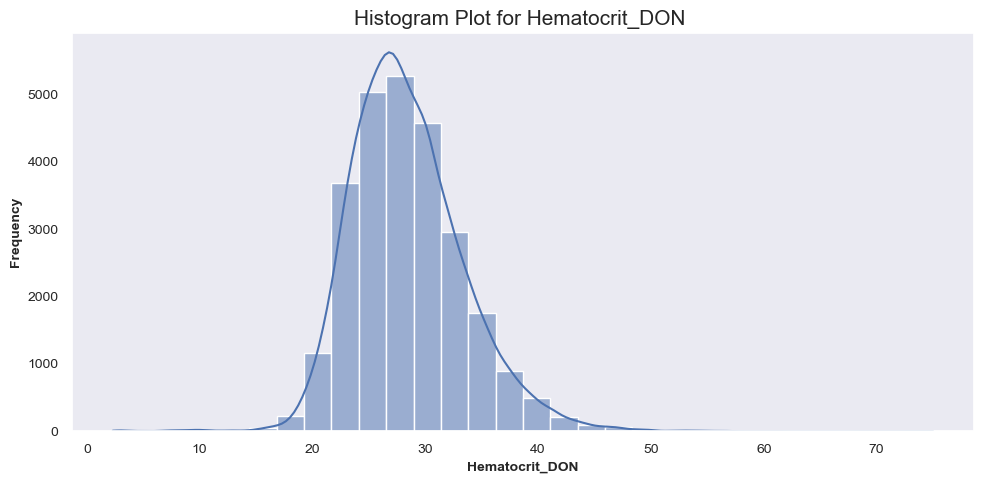

In [100]:
uv.histogramPlot(df_impute, features, bins=30)

In [101]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


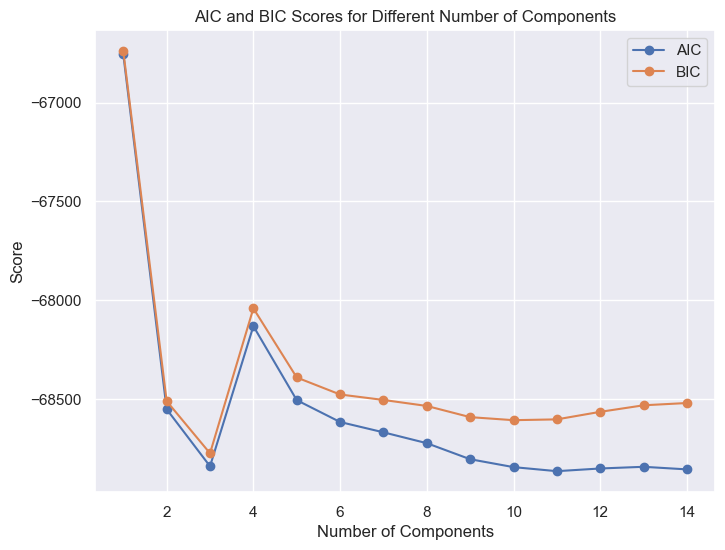

Optimal number of components: 3


In [102]:
# find components
ui.findGaussianMixtureComponents(df_impute[features], component_range=range(1, 15), seed=RANDOM_STATE)

In [103]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=3)

The best n_neighbors for KNN imputer is: 1
The best weights for KNN imputer is: uniform


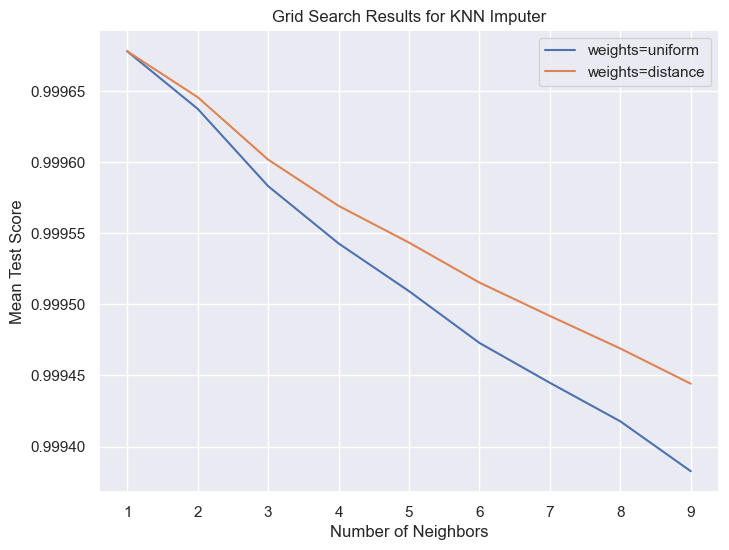

In [104]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [105]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Hematocrit_DON,26600.0,28.403919,5.003041,2.3,25.0,27.9,31.3,75.0


#### LV_EjectionFractionPercent

In [106]:
features = uf.getFeatureList(df_impute, 'LV_EjectionFractionPercent')

                                  count       mean      std   min   25%   50%   75%   max
LV_EjectionFractionPercent_DON  26573.0  61.619139  6.64542  10.0  56.0  60.0  65.0  99.0

:::: NaN Count:
LV_EjectionFractionPercent_DON    27


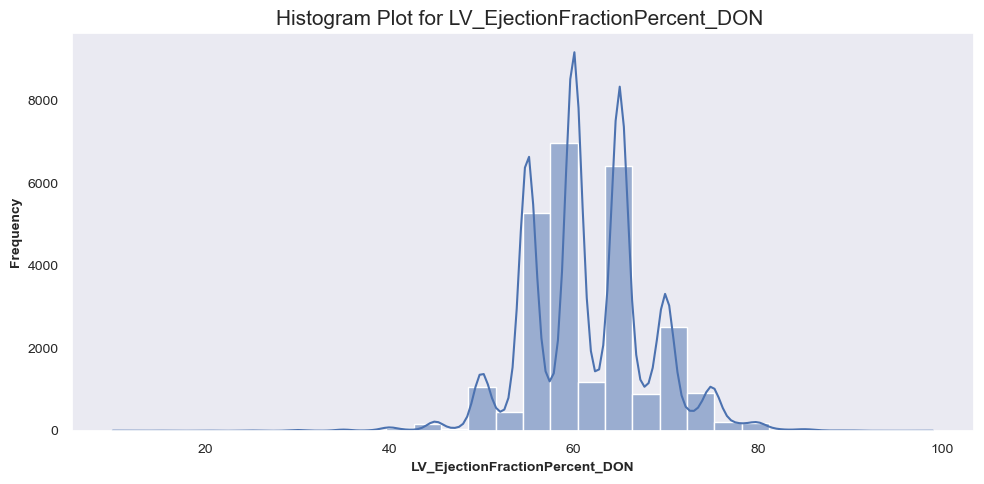

In [107]:
uv.histogramPlot(df_impute, features, bins=30)

array([[<Axes: title={'center': 'LV_EjectionFractionPercent_DON'}>]],
      dtype=object)

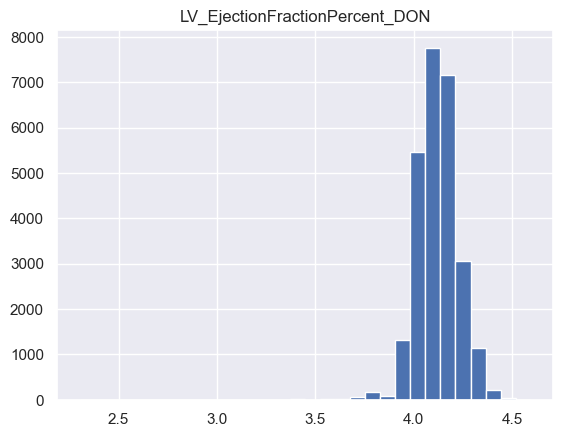

In [108]:
np.log(df[features]).hist(bins=30)

In [109]:
# transformation
df[features] = np.log(df[features])

In [110]:
# stats test
usf.testMCAR(df_impute[features])

Little's MCAR test p-value: nan
Reject null hypothesis: Data is not Missing Completely At Random (MCAR).


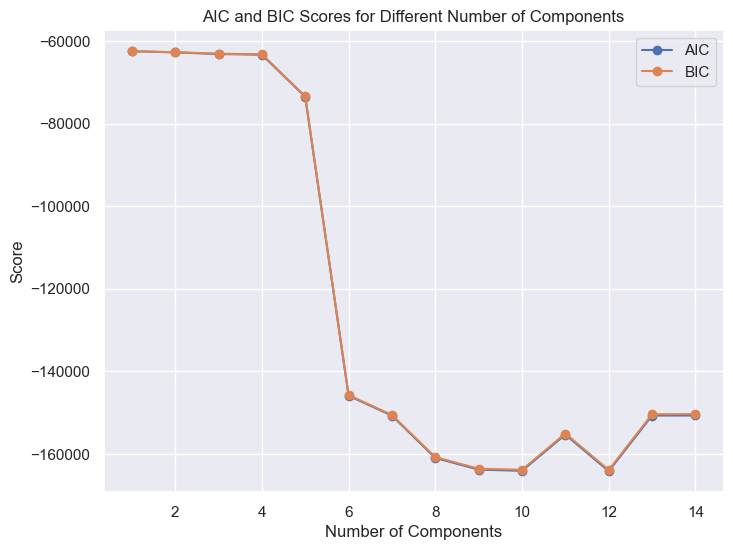

Optimal number of components: 12


In [111]:
# find components
ui.findGaussianMixtureComponents(df_impute[features], component_range=range(1, 15), seed=RANDOM_STATE)

In [112]:
# impute using GMM
imputeGMM = ui.imputeGaussianMixture(df_impute[features], RANDOM_STATE, n_components=12)

The best n_neighbors for KNN imputer is: 1
The best weights for KNN imputer is: uniform


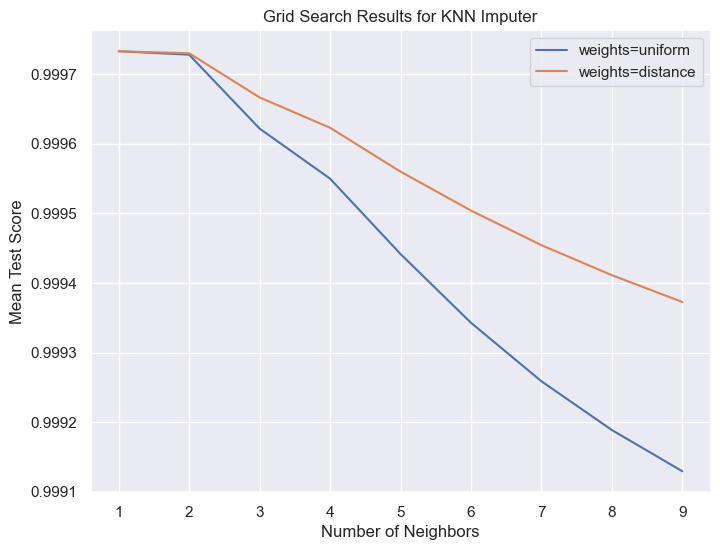

In [113]:
# impute knn
imputeKNN = ui.imputeKNN(df_impute[features])

In [114]:
# calculate the average
imputeAverage = (imputeGMM + imputeKNN) / 2

# update imputed features
df_impute[features] = imputeAverage
# display
df_impute[features].describe().T

,count,mean,std,min,25%,50%,75%,max
LV_EjectionFractionPercent_DON,26600.0,61.619198,6.642804,10.0,56.0,60.0,65.0,99.0


In [115]:
# remove unwanted features
df, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 0 row(s) from df_can DataFrame.
Remove 3 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 1 row(s) from df_nominal DataFrame.
Remove 2 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['LungPO2_DON', 'LungPO2_Done_DON', 'LungPO2_FIO2_DON']

Total Row(s) & Column(s) Before Removing Column(s): 26,600 & columns: 237
Total Row(s) & Column(s) After Removing Column(s): 26,600 & columns: 234


In [116]:
# remove unwanted features Impute
df_impute, df_dict, df_label, df_can, df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date = uf.HouseKeeping(df_impute, removeCols, df_dict, df_label, df_can,\
                                                                df_don, df_both, df_ordinal, df_nominal, df_numeric, df_drop, df_object, df_unknown, df_date, txt=REMOVE, display=True)

Data Dictionary Updated.
Remove 0 row(s) from df_label DataFrame.
Remove 0 row(s) from df_can DataFrame.
Remove 0 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.
Remove 0 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 0 row(s) from df_numeric DataFrame.
Remove 0 row(s) from df_drop DataFrame.
Remove 0 row(s) from df_object DataFrame.
Remove 0 row(s) from df_unknown DataFrame.
Remove 0 row(s) from df_date DataFrame.

Removed Features: ['LungPO2_DON', 'LungPO2_Done_DON', 'LungPO2_FIO2_DON']

Total Row(s) & Column(s) Before Removing Column(s): 26,600 & columns: 237
Total Row(s) & Column(s) After Removing Column(s): 26,600 & columns: 234


#### Examine NaNs: Full Dataset

In [117]:
# get NaNs
NaNsDF = uf.percentageNull(df_impute)

# display NaNs
NaNsDF

,percentage,NaNCount


### Save

In [118]:
# heart dataset
uf.writeToFile(df, '5Heart_ML_Orig',path='../Data/', format='pkl')

# heart dataset
uf.writeToFile(df_impute, '5Heart_ML_Impute',path='../Data/', format='pkl')

# heart label
uf.writeToFile(df_label, '5Label_ML',path='../Data/', format='pkl')

# heart candidate
uf.writeToFile(df_can, '5CAN_ML', format='pkl')

# heart donor
uf.writeToFile(df_don, '5DON_ML', format='pkl')

# heart both
uf.writeToFile(df_both, '5BOTH_ML', format='pkl')

# heart nominal
uf.writeToFile(df_nominal, '5Nominal_ML', format='pkl')

# heart ordinal
uf.writeToFile(df_ordinal, '5Ordinal_ML', format='pkl')

# heart numeric
uf.writeToFile(df_numeric, '5Numeric_ML', format='pkl')

# heart drop
uf.writeToFile(df_drop, '5Drop_ML', format='pkl')

# heart new
uf.writeToFile(df_new, '5New_ML', format='pkl')

# heart object
uf.writeToFile(df_object, '5Object_ML', format='pkl')

# heart unknown
uf.writeToFile(df_unknown, '5Unknown_ML', format='pkl')

# heart date
uf.writeToFile(df_date, '5Date_ML', format='pkl')

# heart data dictionary
uf.writeToFile(df_dict, '5Dictionary_ML', format='pkl')

26,600 records written to ../Data/5Heart_ML_Orig.pkl
26,600 records written to ../Data/5Heart_ML_Impute.pkl
2 records written to ../Data/5Label_ML.pkl
128 records written to ../Data/5CAN_ML.pkl
87 records written to ../Data/5DON_ML.pkl
22 records written to ../Data/5BOTH_ML.pkl
166 records written to ../Data/5Nominal_ML.pkl
12 records written to ../Data/5Ordinal_ML.pkl
57 records written to ../Data/5Numeric_ML.pkl
23 records written to ../Data/5Drop_ML.pkl
22 records written to ../Data/5New_ML.pkl
0 records written to ../Data/5Object_ML.pkl
0 records written to ../Data/5Unknown_ML.pkl
0 records written to ../Data/5Date_ML.pkl
302 records written to ../Data/5Dictionary_ML.pkl
